# Week 12 — A Forward PDE-PINN in PyTorch, Verified Before It Is Believed

Companion notebook to `IS_Wk12_Khong_Chee_Houe_1011006.pptx`. Numerical claims
labelled as Week 12 evidence are produced or archived here.



> **Evidence boundary.** This notebook is a reduced, periodic one-dimensional
> verification and observable-design testbed. The SFF v3.1 manuscript is a
> separate reduced two-dimensional double-elliptical identifiability study.
> Results are not transferred between them unless the model and evidence source
> are stated explicitly.

The governing equation, non-dimensional and periodic on $x\in[0,1)$:

$$\frac{\partial T}{\partial Fo} + Pe\,\frac{\partial T}{\partial x}
 = \frac{\partial^2 T}{\partial x^2} - Bi\,T + Q(x,Fo),
 \qquad T(x,0)=T_0(x)$$

Three cases, each with a closed-form solution:

| | problem | Pe | Bi | Q | $T_0$ |
|---|---|---|---|---|---|
| **A** | pure diffusion | 0 | 0 | — | $\sin 2\pi x + \tfrac12 \sin 6\pi x$ |
| **B** | advection–diffusion–reaction | 20 | 30 | — | $\sin 2\pi x$ |
| **C** | co-moving source diagnostic | 20 | 30 | moving | 0 |

Case **C** is the operator the Week 10 inverse PINN embedded — the same one, not
an imitation, and §2 checks that. It is **not**, however, the WAAM moving-source
problem. As implemented it carries a material advection term at $Pe$ *and* a
source translating at $Pe$: one speed used twice, which cancels exactly in the
source frame. A stationary substrate admits one or the other, never both. §2.1
states the corrected operator and measures what the difference costs. Everything
that follows is a statement about the operator actually solved, which is
well posed and worth measuring — the label was the error, not the results.

**Bundle hash** `32118e0b26f92c3c7d42db9dbc94201f635eb58b…`


*Week 12 addendum (sections 9-13): observable-design information field, a Pe_s Fisher column, the three evidence streams stated separately, a single-solve comparison, and a frozen canonical artifact.*

## 0 · Preflight

In [1]:
import importlib, sys
missing = []
for mod in ("torch", "numpy", "scipy", "matplotlib"):
    try:
        m = importlib.import_module(mod)
        print(f"  OK      {mod:<12} {getattr(m, '__version__', '?')}")
    except ImportError:
        missing.append(mod); print(f"  MISSING {mod}")
if missing:
    print("\n    " + sys.executable + " -m pip install " + " ".join(missing))
    print("\n  Then restart the kernel.")
else:
    print("\nAll present. Kernel:", sys.executable)

  OK      torch        2.10.0
  OK      numpy        2.5.0
  OK      scipy        1.18.0
  OK      matplotlib   3.11.0

All present. Kernel: /opt/homebrew/Caskroom/miniconda/base/envs/torch_m4_clean/bin/python


### RUN_MODE

`archive` reads the stored results and retrains nothing. `quick` reruns a
reduced sweep (one seed, fewer bandwidths) as a reproducibility spot-check.
`full` reruns everything exactly as it was run for the deck — about an hour on
one core.

In [2]:
RUN_MODE = "full"     # "archive" | "quick" | "full"
print("RUN_MODE =", RUN_MODE)

RUN_MODE = full


## 1 · Environment, source, and the bundle hash

In [3]:
import sys, platform, time, json, hashlib
import numpy as np
print('timestamp :', time.strftime('%Y-%m-%d %H:%M:%S'))
print('platform  :', platform.platform(), '|', platform.machine())
import torch
torch.set_num_threads(1); torch.set_default_dtype(torch.float64)
print('torch     :', torch.__version__, '| dtype', torch.get_default_dtype())

timestamp : 2026-08-12 08:06:51
platform  : macOS-26.6.1-arm64-arm-64bit | arm64
torch     : 2.10.0 | dtype torch.float64


In [4]:
SOURCES = json.loads(r'''{
 "inverse1d.py": "\"\"\"Inverse 1-D scaffold for parameter identification from LIMITED, NOISY observations.\n\nForward model (non-dimensional, periodic, exact in Fourier space):\n\n    dT/dFo + Pe dT/dx = d2T/dx2 + Q(x,Fo;A,sq) - Bi*T,     T(x,0)=0\n    Q = A * exp(-(x - x0 - Pe*Fo)^2 / (2 sq^2))            (moving Gaussian source)\n\nUnknown theta = (A, sq, Bi), with Pe KNOWN (travel speed is commanded in WAAM).\n\n    A   <->  eta * U I     absorbed power\n    sq  <->  c_f, c_r      source size\n    Bi  <->  h_eff         heat loss\n\nThe A/sq pair is expected to be confounded when only the diffused far field is\nobserved, because a Gaussian source deposits A*sq*sqrt(2pi) regardless of how that\nproduct is split. This is the 1-D analogue of the eta/b degeneracy.\n\"\"\"\nimport math, time\nimport numpy as np\n\nXQ = 0.30          # source launch position\nNFFT = 256\nFO_END = 0.016\nPE_TRUE = 20.0\nTHETA_TRUE = np.array([1.0, 0.040, 30.0])     # A, sq, Bi\nPNAMES = [\"A\", \"sq\", \"Bi\"]\n\n\n# ------------------------------------------------------------------ forward\ndef _qhat(A, sq, N=NFFT):\n    xg = np.arange(N) / N\n    q0 = A * sum(np.exp(-(xg - XQ + m) ** 2 / (2 * sq ** 2)) for m in (-1, 0, 1))\n    return np.fft.fft(q0) / N\n\n\ndef T_exact(x, fo, theta, pe=PE_TRUE, N=NFFT):\n    \"\"\"Exact solution at arbitrary (x, fo). x, fo broadcast together.\"\"\"\n    A, sq, Bi = theta\n    Qh = _qhat(A, sq, N)\n    n = np.fft.fftfreq(N, d=1.0 / N)\n    k = 2 * np.pi * n\n    d = k ** 2 + Bi\n    x = np.asarray(x, dtype=float)\n    fo = np.asarray(fo, dtype=float)\n    out = np.zeros(np.broadcast(x, fo).shape, dtype=complex)\n    for j in range(N):\n        if abs(d[j]) < 1e-14:\n            coef = Qh[j] * fo\n        else:\n            coef = Qh[j] * np.exp(-1j * k[j] * pe * fo) * (-np.expm1(-d[j] * fo)) / d[j]\n        out = out + coef * np.exp(1j * k[j] * x)\n    return out.real\n\n\n# ------------------------------------------------------------------ sensors\ndef layout(kind):\n    \"\"\"Observation designs, all deliberately sparse -- 'limited experimental data'.\"\"\"\n    if kind == \"TC3\":            # three fixed thermocouples\n        xs = np.array([0.25, 0.50, 0.75]); ts = np.linspace(0.002, FO_END, 12)\n    elif kind == \"TC8\":          # eight fixed thermocouples\n        xs = np.linspace(0.10, 0.90, 8);   ts = np.linspace(0.002, FO_END, 12)\n    elif kind == \"SCAN\":         # IR line scan: dense in space, four frames\n        xs = np.linspace(0.02, 0.98, 40);  ts = np.array([0.004, 0.008, 0.012, 0.016])\n    elif kind == \"NEAR\":         # three sensors placed close to the source path\n        xs = np.array([0.32, 0.42, 0.52]); ts = np.linspace(0.002, FO_END, 12)\n    else:\n        raise ValueError(kind)\n    X, T = np.meshgrid(xs, ts, indexing=\"ij\")\n    return X.ravel(), T.ravel()\n\n\ndef comoving(nx=12, nt=12):\n    \"\"\"Sensor that travels with the source (co-moving pyrometer).\"\"\"\n    xi = np.linspace(-0.10, 0.10, nx)\n    ts = np.linspace(0.002, FO_END, nt)\n    XI, T = np.meshgrid(xi, ts, indexing=\"ij\")\n    return (XQ + PE_TRUE * T + XI).ravel() % 1.0, T.ravel()\n\n\ndef synth_data(kind, noise_pct, seed=0, theta=THETA_TRUE):\n    \"\"\"Noiseless truth -> add Gaussian sensor noise scaled to the signal peak.\"\"\"\n    xs, ts = comoving() if kind == \"COMOV\" else layout(kind)\n    clean = T_exact(xs, ts, theta)          # vectorised\n    sigma = noise_pct * np.abs(clean).max()\n    rng = np.random.default_rng(seed)\n    return xs, ts, clean + rng.normal(0.0, sigma, clean.shape), clean, sigma\n\n\n# ------------------------------------------------------- identifiability gate\ndef jacobian(xs, ts, theta, rel=1e-6):\n    \"\"\"dT/dtheta at the sensor points, by central differences on the exact model.\"\"\"\n    J = np.zeros((len(xs), len(theta)))\n    base = T_exact(xs, ts, theta)\n    for j in range(len(theta)):\n        h = rel * max(abs(theta[j]), 1e-8)\n        tp = theta.copy(); tp[j] += h\n        tm = theta.copy(); tm[j] -= h\n        up = T_exact(xs, ts, tp); dn = T_exact(xs, ts, tm)\n        J[:, j] = (up - dn) / (2 * h)\n    return J, base\n\n\ndef fisher(xs, ts, theta, sigma):\n    \"\"\"FIM, its conditioning, Cramer-Rao bounds and the degenerate direction.\"\"\"\n    J, base = jacobian(xs, ts, theta)\n    F = J.T @ J / sigma ** 2\n    U, S, Vt = np.linalg.svd(J)\n    cond = S[0] / S[-1]\n    try:\n        C = np.linalg.inv(F)\n        crb = np.sqrt(np.diag(C))\n        corr = C / np.outer(np.sqrt(np.diag(C)), np.sqrt(np.diag(C)))\n    except np.linalg.LinAlgError:\n        crb = np.full(len(theta), np.inf); corr = np.full((3, 3), np.nan)\n    return dict(J=J, F=F, sv=S, cond=cond, crb=crb, corr=corr,\n                worst_dir=Vt[-1], rel_crb=crb / np.abs(theta), n_obs=len(xs))\n\n\n# --------------------------------------------------------------- LM baseline\ndef lm_fit(xs, ts, obs, sigma, theta0, bounds=None):\n    from scipy.optimize import least_squares\n    def resid(lp):\n        th = np.exp(lp)\n        return (T_exact(xs, ts, th) - obs) / sigma\n    t0 = time.time()\n    r = least_squares(resid, np.log(theta0), method=\"lm\", xtol=1e-12, ftol=1e-12)\n    th = np.exp(r.x)\n    # covariance from the Gauss-Newton approximation, in log space -> delta method\n    JtJ = r.jac.T @ r.jac\n    try:\n        Clog = np.linalg.inv(JtJ)\n        se = np.sqrt(np.diag(Clog)) * th          # delta method\n    except np.linalg.LinAlgError:\n        se = np.full(3, np.inf)\n    return dict(theta=th, se=se, nfev=r.nfev, cost=r.cost,\n                wall=time.time() - t0, success=r.success)\n\n\ndef fisher_scaled(xs, ts, theta, sigma):\n    \"\"\"Scale-free identifiability: use RELATIVE sensitivities theta_j * dT/dtheta_j,\n    otherwise the SVD just reports which parameter has the largest units.\"\"\"\n    J, base = jacobian(xs, ts, theta)\n    Js = J * theta[None, :]\n    U, S, Vt = np.linalg.svd(Js, full_matrices=False)\n    F = Js.T @ Js / sigma ** 2\n    try:\n        C = np.linalg.inv(F)\n        rel_crb = np.sqrt(np.diag(C))\n        corr = C / np.outer(np.sqrt(np.diag(C)), np.sqrt(np.diag(C)))\n    except np.linalg.LinAlgError:\n        rel_crb = np.full(3, np.inf); corr = np.full((3, 3), np.nan)\n    return dict(sv=S, cond=S[0] / S[-1], rel_crb=rel_crb, corr=corr,\n                worst_dir=Vt[-1], n_obs=len(xs), Js=Js)\n\n\ndef lm_multistart(xs, ts, obs, sigma, starts=None):\n    \"\"\"LM from several starting points; keep the lowest-cost fit. Averaging raw fits\n    across seeds hides non-convergence, so callers should report medians.\"\"\"\n    if starts is None:\n        starts = [np.array([0.5, 0.020, 10.0]),\n                  np.array([2.0, 0.080, 60.0]),\n                  np.array([1.0, 0.040, 30.0]) * 1.5]\n    best = None\n    for s0 in starts:\n        try:\n            r = lm_fit(xs, ts, obs, sigma, s0)\n        except Exception:\n            continue\n        if best is None or r[\"cost\"] < best[\"cost\"]:\n            best = r\n    return best\n",
 "inverse1d_frames.py": "\"\"\"Corrected forward oracle: one travel speed, used once.\n\nThe scaffold as written solves\n\n    T_Fo + Pe T_x = T_xx - L T + Q(x - x0 - Pe Fo)\n\nwhich carries material advection at Pe *and* a source translating at Pe. For a\nstationary substrate that is the same speed twice, and the two cancel in the\nsource frame. The physical problem admits exactly one of:\n\n    frame=\"lab\"     T_Fo              = T_xx - L T + Q(x - x0 - Pe_s Fo)\n    frame=\"source\"  W_Fo - Pe_s W_xi  = W_xi_xi - L W + Q(xi)\n\nrelated by W(xi, Fo) = T(xi + Pe_s Fo, Fo). The double-counted form is retained\nas frame=\"comoving\" so archived results stay reproducible, but it is a\ndiagnostic, not the WAAM model.\n\nTransfer functions, all with T(x,0) = 0 and d = k^2 + L - i k Pe_s:\n\n    lab       T_k = q_k [ e^{-i k Pe_s Fo} - e^{-(k^2+L) Fo} ] / d\n    source    W_k = q_k [ 1 - e^{-d Fo} ] / d\n    comoving  T_k = q_k e^{-i k Pe_s Fo} [ 1 - e^{-(k^2+L) Fo} ] / (k^2 + L)\n\"\"\"\nimport numpy as np\n\nfrom inverse1d import _qhat, XQ, NFFT, FO_END, PE_TRUE, THETA_TRUE\n\n\ndef T_exact_frame(x, fo, theta, pe=PE_TRUE, N=NFFT, frame=\"source\"):\n    A, sq, L = theta\n    Qh = _qhat(A, sq, N)\n    k = 2 * np.pi * np.fft.fftfreq(N, d=1.0 / N)\n    x = np.asarray(x, dtype=float)\n    fo = np.asarray(fo, dtype=float)\n    out = np.zeros(np.broadcast(x, fo).shape, dtype=complex)\n\n    d_pure = k ** 2 + L                       # no speed in the denominator\n    d_adv = k ** 2 + L - 1j * k * pe          # speed enters every mode\n\n    for j in range(N):\n        if frame == \"source\":\n            dj = d_adv[j]\n            coef = Qh[j] * (-np.expm1(-dj * fo)) / dj\n        elif frame == \"lab\":\n            dj = d_adv[j]\n            coef = Qh[j] * (np.exp(-1j * k[j] * pe * fo)\n                            - np.exp(-d_pure[j] * fo)) / dj\n        elif frame == \"comoving\":             # the double-counted scaffold\n            dj = d_pure[j]\n            coef = (Qh[j] * np.exp(-1j * k[j] * pe * fo)\n                    * (-np.expm1(-dj * fo)) / dj)\n        else:\n            raise ValueError(frame)\n        out = out + coef * np.exp(1j * k[j] * x)\n    return out.real\n\n\n# ------------------------------------------------------------------ checks\ndef _grid(nx=NFFT):\n    return np.arange(nx) / nx, 2 * np.pi * np.fft.fftfreq(nx, d=1.0 / nx)\n\n\ndef _src(x, theta, moving_at=None, fo=0.0):\n    A, sq, _ = theta\n    c = XQ + (moving_at * fo if moving_at else 0.0)\n    return A * sum(np.exp(-(x - c + m) ** 2 / (2 * sq ** 2)) for m in (-1, 0, 1))\n\n\ndef check_mol(theta, pe, fo_end, frame):\n    \"\"\"Independent spectral method-of-lines integration of the same frame.\"\"\"\n    from scipy.integrate import solve_ivp\n    xg, k = _grid()\n    L = theta[2]\n\n    def rhs(t, T):\n        Th = np.fft.fft(T)\n        Tx = np.fft.ifft(1j * k * Th).real\n        Txx = np.fft.ifft(-(k ** 2) * Th).real\n        if frame == \"lab\":\n            q = _src(xg, theta, moving_at=pe, fo=t)\n            return Txx - L * T + q                    # no advection\n        if frame == \"source\":\n            q = _src(xg, theta)\n            return pe * Tx + Txx - L * T + q          # one advection term\n        q = _src(xg, theta, moving_at=pe, fo=t)\n        return -pe * Tx + Txx - L * T + q             # comoving: both\n    s = solve_ivp(rhs, (0, fo_end), np.zeros(NFFT), method=\"Radau\",\n                  rtol=1e-11, atol=1e-13, dense_output=True)\n    num = s.sol(fo_end)\n    ref = T_exact_frame(xg, np.full(NFFT, fo_end), theta, pe, frame=frame)\n    return np.linalg.norm(num - ref) / np.linalg.norm(ref)\n\n\nif __name__ == \"__main__\":\n    th, pe, fe = THETA_TRUE, PE_TRUE, FO_END\n    print(\"solution verified against an independent integrator\")\n    for fr in (\"lab\", \"source\", \"comoving\"):\n        print(f\"   frame={fr:<9} rel-L2 = {check_mol(th, pe, fe, fr):.3e}\")\n\n    xg, _ = _grid()\n    lab = T_exact_frame(xg, np.full(NFFT, fe), th, pe, frame=\"lab\")\n    src = T_exact_frame((xg - pe * fe) % 1.0, np.full(NFFT, fe), th, pe,\n                        frame=\"source\")\n    print(f\"\\nlab and source frames agree under translation: \"\n          f\"rel-L2 = {np.linalg.norm(lab - src)/np.linalg.norm(lab):.3e}\")\n\n    print(\"\\nspeed sensitivity of the field (rel-L2 against Pe_s = 0)\")\n    for fr in (\"source\", \"comoving\"):\n        ref0 = T_exact_frame(xg, np.full(NFFT, fe), th, 0.0, frame=fr)\n        row = []\n        for p in (5.0, 20.0, 50.0):\n            w = T_exact_frame(xg, np.full(NFFT, fe), th, p, frame=fr)\n            row.append(np.linalg.norm(w - ref0) / np.linalg.norm(ref0))\n        print(f\"   frame={fr:<9} Pe=5 {row[0]:.3f}   Pe=20 {row[1]:.3f}   \"\n              f\"Pe=50 {row[2]:.3f}\")\n",
 "forward_pinn.py": "\"\"\"Forward PDE-based PINN in PyTorch \u2014 Week 11.\n\nGoverning equation (non-dimensional, periodic on x in [0,1)):\n\n    dT/dFo + Pe dT/dx = d2T/dx2 - Bi*T + Q(x,Fo),      T(x,0) = T0(x)\n\nThree cases of increasing difficulty, each with a closed-form solution:\n\n    A  DIFF   Pe=0,  Bi=0,  Q=0,   T0 = sin(2pi x) + 0.5 sin(6pi x)\n    B  ADR    Pe=20, Bi=30, Q=0,   T0 = sin(2pi x)\n    C  SRC    Pe=20, Bi=30, Q=moving Gaussian, T0 = 0     <- Week 10's operator\n\nThe network is built in seven steps, in the order the tensors flow:\n\n    1. Fourier feature embedding in x        -> periodic BC is EXACT\n    2. hard initial condition by ansatz      -> L_IC is identically zero\n    3. autodiff residual (T_Fo, T_x, T_xx)   -> the only loss term\n    4. residual normalisation by D0          -> loss is O(1) at initialisation\n    5. Sobol collocation in (x, Fo)\n    6. Adam + cosine anneal -> L-BFGS/strong Wolfe, float64 throughout\n    7. accuracy measured against the exact solution, never against the loss\n\nBecause steps 1 and 2 are exact by construction, L_total = L_PDE alone. There\nis no boundary term and no initial-condition term, hence no weights to balance\nbetween them: the Week 8 loss-balancing problem is REMOVED here rather than\ntuned. That is the main structural point of this week.\n\"\"\"\nimport math\nimport time\n\nimport numpy as np\nimport torch\nimport torch.nn as nn\n\nfrom inverse1d import _qhat, THETA_TRUE, PE_TRUE, XQ, FO_END, NFFT\n\ntorch.set_num_threads(1)\ntorch.set_default_dtype(torch.float64)\n\n\n# =========================================================== 1. the test cases\nclass Case:\n    \"\"\"A forward problem: coefficients, initial condition, source, exact solution.\n\n    `d0` is the magnitude of dT/dFo at Fo=0 implied by the PDE itself:\n\n        dT/dFo|_0 = T0'' - Pe*T0' - Bi*T0 + Q(x,0)\n\n    It is computable WITHOUT the exact solution, and is used both to normalise\n    the residual (step 4) and to predict the amplitude the network must reach\n    under the hard-IC ansatz (step 2).\n    \"\"\"\n\n    def __init__(self, name, pe, bi, fo_end, t0, exact, q=None):\n        self.name = name\n        self.pe = pe\n        self.bi = bi\n        self.fo_end = fo_end\n        self.t0 = t0\n        self.exact = exact\n        self.q = q\n        self.d0 = self._compute_d0()\n\n    def _compute_d0(self, nx=1024):\n        x = torch.arange(nx, dtype=torch.float64).reshape(-1, 1) / nx\n        x.requires_grad_(True)\n        T0 = self.t0(x)\n\n        def d_dx(u):\n            \"\"\"One derivative, returning exact zeros when u is constant in x.\"\"\"\n            if not u.requires_grad:\n                return torch.zeros_like(u)\n            return torch.autograd.grad(u, x, torch.ones_like(u),\n                                       create_graph=True, allow_unused=True,\n                                       materialize_grads=True)[0]\n\n        g = d_dx(T0)\n        gg = d_dx(g)\n        rhs = gg.detach() - self.pe * g.detach() - self.bi * T0.detach()\n        if self.q is not None:\n            rhs = rhs + self.q(x.detach(), torch.zeros_like(x))\n        return float(rhs.abs().max())\n\n    def source(self, x, fo):\n        return self.q(x, fo) if self.q is not None else torch.zeros_like(x)\n\n\ndef _q_moving(x, fo):\n    \"\"\"Week 10's periodised moving Gaussian, in torch.\"\"\"\n    A, sq, _ = THETA_TRUE\n    c = XQ + PE_TRUE * fo\n    return A * sum(torch.exp(-(x - c + m) ** 2 / (2 * sq ** 2)) for m in (-1, 0, 1))\n\n\ndef _exact_C(x, fo):\n    \"\"\"Week 10's Fourier solution, re-expressed in torch so it is differentiable.\n\n    T = sum_j g_j(Fo) * [ Re(Qh_j) cos(phi_j) - Im(Qh_j) sin(phi_j) ],\n        phi_j = k_j (x - Pe*Fo),   g_j = (1 - exp(-d_j Fo)) / d_j,  d_j = k_j^2 + Bi\n    \"\"\"\n    A, sq, Bi = THETA_TRUE\n    Qh = _qhat(A, sq, NFFT)\n    k = torch.tensor(2 * np.pi * np.fft.fftfreq(NFFT, d=1.0 / NFFT))\n    ar = torch.tensor(Qh.real)\n    ai = torch.tensor(Qh.imag)\n    d = k ** 2 + Bi\n    phi = k * (x - PE_TRUE * fo)                       # (n, NFFT) by broadcasting\n    g = -torch.expm1(-d * fo) / d\n    return (g * (ar * torch.cos(phi) - ai * torch.sin(phi))).sum(1, keepdim=True)\n\n\ndef case_A():\n    \"\"\"Pure diffusion. Two modes, 9x separation in decay rate.\"\"\"\n    def t0(x):\n        return torch.sin(2 * math.pi * x) + 0.5 * torch.sin(6 * math.pi * x)\n\n    def ex(x, fo):\n        return (torch.exp(-((2 * math.pi) ** 2) * fo) * torch.sin(2 * math.pi * x)\n                + 0.5 * torch.exp(-((6 * math.pi) ** 2) * fo)\n                * torch.sin(6 * math.pi * x))\n\n    return Case(\"A_diffusion\", 0.0, 0.0, 0.020, t0, ex)\n\n\ndef case_B():\n    \"\"\"Advection-diffusion-reaction. Same Pe and Bi as the Week 10 operator.\"\"\"\n    def t0(x):\n        return torch.sin(2 * math.pi * x)\n\n    def ex(x, fo):\n        lam = (2 * math.pi) ** 2 + 30.0\n        return torch.exp(-lam * fo) * torch.sin(2 * math.pi * (x - 20.0 * fo))\n\n    return Case(\"B_adv_diff_reac\", 20.0, 30.0, 0.016, t0, ex)\n\n\ndef case_C():\n    \"\"\"Moving Gaussian source: exactly the operator Week 10's inverse PINN solved.\"\"\"\n    # 0.0 * x rather than zeros_like(x): keeps T0 on the autograd graph so the\n    # same d0 routine works for every case without a special branch.\n    return Case(\"C_moving_source\", PE_TRUE, 30.0, FO_END,\n                lambda x: 0.0 * x, _exact_C, _q_moving)\n\n\nCASES = {\"A\": case_A, \"B\": case_B, \"C\": case_C}\n\n\n# ================================================================ 2. the model\ndef fourier_features(x, K):\n    \"\"\"Step 1. gamma(x) = [sin(2pi k x), cos(2pi k x)] for k = 1..K.\n\n    Every feature is 1-periodic, so ANY network of these features is periodic.\n    The boundary condition is satisfied identically, not penalised.\n    \"\"\"\n    ks = torch.arange(1, K + 1, dtype=x.dtype)\n    a = 2 * math.pi * x * ks\n    return torch.cat([torch.sin(a), torch.cos(a)], 1)\n\n\nclass ForwardPINN(nn.Module):\n    \"\"\"T(x,Fo) = T0(x) + (Fo/Fo_end) * N(gamma(x), Fo/Fo_end)\n\n    The prefactor vanishes at Fo=0, so T(x,0) = T0(x) exactly for any weights:\n    that is step 2, the hard initial condition.\n\n    Consequence worth noting: the network does not represent T. Differentiating\n    the ansatz at Fo=0 and matching the PDE gives\n\n        N(x, 0) = Fo_end * [ T0'' - Pe*T0' - Bi*T0 + Q(x,0) ] = Fo_end * O(d0)\n\n    so the amplitude the network must reach is set by the PDE, not by the size\n    of T. `predicted_amplitude` below states that number before training.\n    \"\"\"\n\n    def __init__(self, case, K=8, width=48, depth=4, seed=0):\n        super().__init__()\n        torch.manual_seed(seed)\n        self.case = case\n        self.K = K\n        layers, d = [], 2 * K + 1\n        for _ in range(depth):\n            layers += [nn.Linear(d, width), nn.Tanh()]\n            d = width\n        layers += [nn.Linear(d, 1)]\n        self.net = nn.Sequential(*layers)\n\n    def predicted_amplitude(self):\n        return self.case.fo_end * self.case.d0\n\n    def forward(self, x, fo):\n        s = fo / self.case.fo_end\n        z = torch.cat([fourier_features(x, self.K), s], 1)\n        return self.case.t0(x) + s * self.net(z)\n\n    def residual(self, x, fo):\n        \"\"\"Step 3. Exact derivatives of the ansatz by reverse-mode autodiff.\"\"\"\n        x = x.requires_grad_(True)\n        fo = fo.requires_grad_(True)\n        T = self.forward(x, fo)\n        Tx, Tfo = torch.autograd.grad(T, [x, fo], torch.ones_like(T),\n                                      create_graph=True)\n        Txx = torch.autograd.grad(Tx, x, torch.ones_like(Tx), create_graph=True)[0]\n        return (Tfo + self.case.pe * Tx - Txx\n                + self.case.bi * T - self.case.source(x, fo))\n\n\n# =========================================================== 3. training utils\ndef sobol(n, fo_end, seed=0):\n    \"\"\"Step 5. Low-discrepancy collocation in (x, Fo).\"\"\"\n    from scipy.stats import qmc\n    m = int(math.ceil(math.log2(n)))\n    p = qmc.Sobol(d=2, scramble=True, seed=seed).random_base2(m)[:n]\n    return (torch.tensor(p[:, 0:1]), torch.tensor(p[:, 1:2]) * fo_end)\n\n\ndef rel_l2(model, case, nx=200, nfo=40):\n    \"\"\"Step 7. Accuracy against the exact solution on a dense grid.\"\"\"\n    xg = torch.arange(nx, dtype=torch.float64).reshape(-1, 1) / nx\n    fg = torch.linspace(0.0, case.fo_end, nfo, dtype=torch.float64).reshape(-1, 1)\n    X = xg.repeat(nfo, 1)\n    F = fg.repeat_interleave(nx, 0)\n    with torch.no_grad():\n        pred = model(X, F)\n    ref = case.exact(X, F)\n    return float(torch.linalg.norm(pred - ref) / torch.linalg.norm(ref))\n\n\ndef train(case, K=8, width=48, depth=4, seed=0, n_col=2048,\n          n_adam=1500, n_lbfgs=800, lr=3e-3, normalise=True,\n          hard_ic=True, resample=False, verbose=False):\n    \"\"\"Step 6. Adam with cosine annealing, then L-BFGS with strong Wolfe.\"\"\"\n    model = ForwardPINN(case, K=K, width=width, depth=depth, seed=seed)\n    if not hard_ic:\n        model.forward = _soft_forward.__get__(model)     # ablation, see below\n    xc, fc = sobol(n_col, case.fo_end, seed)\n    rn = case.d0 if normalise else 1.0\n\n    xi = torch.rand(512, 1, generator=torch.Generator().manual_seed(seed + 7))\n    fi = torch.zeros(512, 1)\n\n    def loss():\n        L = ((model.residual(xc, fc) / rn) ** 2).mean()\n        if not hard_ic:                                   # soft IC needs a term\n            L = L + 100.0 * ((model(xi, fi) - case.t0(xi)) ** 2).mean()\n        return L\n\n    t0 = time.time()\n    opt = torch.optim.Adam(model.parameters(), lr=lr)\n    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_adam, eta_min=1e-4)\n    hist = []\n    for i in range(n_adam):\n        if resample and i % 100 == 0 and i > 0:\n            xc, fc = sobol(n_col, case.fo_end, seed + i)\n        opt.zero_grad()\n        L = loss()\n        L.backward()\n        opt.step()\n        sch.step()\n        if i % 250 == 0:\n            hist.append((i, float(L.detach()), rel_l2(model, case, 100, 20)))\n            if verbose:\n                print(f\"      adam {i:>5}  L={float(L):.3e}  \"\n                      f\"relL2={hist[-1][2]:.3e}\", flush=True)\n\n    lb = torch.optim.LBFGS(model.parameters(), max_iter=n_lbfgs, history_size=60,\n                           tolerance_grad=1e-14, tolerance_change=1e-16,\n                           line_search_fn=\"strong_wolfe\")\n\n    def closure():\n        lb.zero_grad()\n        L = loss()\n        L.backward()\n        return L\n\n    lb.step(closure)\n\n    with torch.no_grad():\n        s = torch.rand(400, 1)\n        amp = float(model.net(torch.cat([fourier_features(s, model.K),\n                                         torch.zeros_like(s)], 1)).abs().max())\n    return dict(case=case.name, K=K, width=width, depth=depth, seed=seed,\n                normalise=normalise, hard_ic=hard_ic, resample=resample,\n                n_col=n_col,\n                rel_l2=rel_l2(model, case),\n                loss=float(loss().detach()),\n                amp_measured=amp,\n                amp_predicted=case.fo_end * case.d0,\n                wall=time.time() - t0, hist=hist), model\n\n\ndef _soft_forward(self, x, fo):\n    \"\"\"Ablation: no hard IC. T = N(gamma(x), Fo/Fo_end), IC enforced by penalty.\"\"\"\n    s = fo / self.case.fo_end\n    z = torch.cat([fourier_features(x, self.K), s], 1)\n    return self.net(z)\n\n\n# ==================================================== 4. operator verification\ndef verify_operator(case, n=512, seed=0):\n    \"\"\"Substitute the EXACT solution into the autodiff residual.\n\n    This tests the PyTorch operator that the PINN minimises, independently of\n    any training. A correct operator returns zero to machine precision. Two\n    bugs were caught this way rather than by reading the code.\n    \"\"\"\n    g = torch.Generator().manual_seed(seed)\n    x = torch.rand(n, 1, generator=g, dtype=torch.float64).requires_grad_(True)\n    fo = (torch.rand(n, 1, generator=g, dtype=torch.float64)\n          * 0.9 * case.fo_end + 0.05 * case.fo_end).requires_grad_(True)\n    T = case.exact(x, fo)\n    Tx, Tfo = torch.autograd.grad(T, [x, fo], torch.ones_like(T), create_graph=True)\n    Txx = torch.autograd.grad(Tx, x, torch.ones_like(Tx), create_graph=True)[0]\n    r = Tfo + case.pe * Tx - Txx + case.bi * T - case.source(x, fo)\n    scale = max(float(Tfo.detach().abs().max()),\n                float(Txx.detach().abs().max()), 1.0)\n    return float(r.detach().abs().max()) / scale\n\n\nif __name__ == \"__main__\":\n    print(f\"{'case':<18}{'Pe':>6}{'Bi':>6}{'Fo_end':>9}\"\n          f\"{'d0':>12}{'amp_pred':>12}{'operator':>13}\")\n    print(\"-\" * 76)\n    for key in \"ABC\":\n        c = CASES[key]()\n        e = verify_operator(c)\n        print(f\"{c.name:<18}{c.pe:>6.0f}{c.bi:>6.0f}{c.fo_end:>9.3f}\"\n              f\"{c.d0:>12.4f}{c.fo_end * c.d0:>12.4f}{e:>13.2e}\")\n    print(\"-\" * 76)\n",
 "param_pinn.py": "\"\"\"Parametric (operator) PINN: T_NN(x, Fo, theta).\n\nBecause theta is an INPUT, it appears inside T_NN and therefore inside L_data.\nThe gradient pathway that the standard inverse PINN lacks is restored by\nconstruction. Trained on physics alone over a theta prior, then theta is fitted\nto the noisy observations with the network frozen.\n\"\"\"\nimport math, time\nimport numpy as np, torch, torch.nn as nn\nfrom inverse1d import T_exact, synth_data, THETA_TRUE, PE_TRUE, XQ, FO_END\n\ntorch.set_num_threads(1); torch.set_default_dtype(torch.float64)\nLO = torch.log(torch.tensor([0.30, 0.015,  5.0]))\nHI = torch.log(torch.tensor([3.00, 0.100, 100.0]))\n\n\ndef embed(x, K=16):\n    ks = torch.arange(1, K + 1, dtype=x.dtype)\n    a = 2 * math.pi * x * ks\n    return torch.cat([torch.sin(a), torch.cos(a)], 1)\n\n\nclass ParamPINN(nn.Module):\n    def __init__(self, width=64, depth=4, K=16, seed=0):\n        super().__init__(); torch.manual_seed(seed); self.K = K\n        L, d = [], 2 * K + 1 + 3\n        for _ in range(depth):\n            L += [nn.Linear(d, width), nn.Tanh()]; d = width\n        L += [nn.Linear(d, 1)]\n        self.net = nn.Sequential(*L)\n\n    def forward(self, x, fo, logth):\n        th = (logth - LO) / (HI - LO) * 2 - 1               # normalise to [-1,1]\n        if th.dim() == 1:\n            th = th.expand(x.shape[0], 3)\n        z = torch.cat([embed(x, self.K), fo / FO_END, th], 1)\n        return (fo / FO_END) * self.net(z)\n\n    def residual(self, x, fo, logth):\n        x = x.requires_grad_(True); fo = fo.requires_grad_(True)\n        T = self.forward(x, fo, logth)\n        Tx, Tfo = torch.autograd.grad(T, [x, fo], torch.ones_like(T), create_graph=True)\n        Txx = torch.autograd.grad(Tx, x, torch.ones_like(Tx), create_graph=True)[0]\n        A, sq, Bi = torch.exp(logth)\n        c = XQ + PE_TRUE * fo\n        Q = A * sum(torch.exp(-(x - c + m) ** 2 / (2 * sq ** 2)) for m in (-1, 0, 1))\n        return Tfo + PE_TRUE * Tx - Txx - Q + Bi * T\n\n\ndef pretrain(steps=1200, ncol=768, seed=0, log_every=300):\n    m = ParamPINN(seed=seed)\n    o = torch.optim.Adam(m.parameters(), lr=3e-3)\n    s = torch.optim.lr_scheduler.CosineAnnealingLR(o, steps, eta_min=1e-4)\n    g = torch.Generator().manual_seed(seed)\n    t0 = time.time()\n    for i in range(steps):\n        x = torch.rand(ncol, 1, generator=g)\n        fo = torch.rand(ncol, 1, generator=g) * FO_END\n        lt = LO + torch.rand(3, generator=g) * (HI - LO)\n        A = float(torch.exp(lt[0])); sq = float(torch.exp(lt[1]))\n        rn = A                      # natural residual scale: the source is O(A).\n                                    # rn = A/FO_END (earlier) shrank the loss ~60x\n                                    # and made an undertrained net look converged.\n        o.zero_grad()\n        L = ((m.residual(x, fo, lt) / rn) ** 2).mean()\n        L.backward(); o.step(); s.step()\n        if log_every and i % log_every == 0:\n            print(f\"    step {i:>5}  physics loss {L.item():.3e}  {time.time()-t0:5.0f}s\",\n                  flush=True)\n    return m, time.time() - t0\n\n\ndef surrogate_error(m, ntest=6, seed=99):\n    \"\"\"How good is the frozen operator surrogate, independent of any inversion?\"\"\"\n    g = torch.Generator().manual_seed(seed)\n    errs = []\n    for _ in range(ntest):\n        lt = LO + torch.rand(3, generator=g) * (HI - LO)\n        th = np.exp(lt.numpy())\n        xg = np.linspace(0, 1, 120, endpoint=False)\n        fg = np.linspace(0.002, FO_END, 8)\n        X, F = np.meshgrid(xg, fg, indexing=\"ij\")\n        ref = T_exact(X.ravel(), F.ravel(), th)\n        with torch.no_grad():\n            pred = m(torch.tensor(X.ravel()).reshape(-1, 1),\n                     torch.tensor(F.ravel()).reshape(-1, 1), lt).numpy().ravel()\n        errs.append(np.linalg.norm(pred - ref) / np.linalg.norm(ref))\n    return float(np.median(errs)), errs\n\n\ndef invert(m, layout=\"COMOV\", pct=0.05, seed=0, steps=400):\n    \"\"\"Fit theta to noisy data with the network frozen. L_data is now a function\n    of theta, so the gradient pathway exists.\"\"\"\n    xs, ts, obs, clean, sig = synth_data(layout, pct, seed=seed)\n    xo = torch.tensor(xs).reshape(-1, 1); to = torch.tensor(ts).reshape(-1, 1)\n    yo = torch.tensor(obs).reshape(-1, 1)\n    for p in m.parameters():\n        p.requires_grad_(False)\n    lt = torch.tensor(np.log([0.5, 0.020, 10.0]), requires_grad=True)\n    o = torch.optim.Adam([lt], lr=2e-2)\n    gnorm0 = None\n    for i in range(steps):\n        o.zero_grad()\n        L = (((m(xo, to, lt) - yo) / sig) ** 2).mean()\n        L.backward()\n        if i == 0:\n            gnorm0 = float(lt.grad.norm())\n        o.step()\n        with torch.no_grad():\n            lt.clamp_(LO, HI)\n    th = torch.exp(lt).detach().numpy()\n    return th, gnorm0, float(L.detach())\n",
 "verify_oracle.py": "\"\"\"Independent checks on the exact solutions used as ground truth in Week 11.\n\nNothing in this week's results is allowed to rest on a loss curve, so the\nreference solutions are themselves verified two ways before any network is\ntrained:\n\n  [1] spectral method-of-lines: integrate the PDE numerically with an\n      independent solver (Radau, spectral x-derivatives) and compare to the\n      closed-form solution.\n  [2] residual substitution: push the closed-form solution through the PDE\n      operator (spectral in x, 5-point central difference in Fo). A correct\n      solution returns zero.\n\nCheck [2] is the important one: it tests the OPERATOR, which is the same\noperator the PINN's autodiff residual implements.\n\"\"\"\nimport numpy as np\nfrom scipy.integrate import solve_ivp\n\nfrom inverse1d import T_exact, THETA_TRUE, PE_TRUE, XQ, FO_END\n\nNX = 256\n\n\ndef _grid(nx=NX):\n    x = np.arange(nx) / nx\n    k = 2 * np.pi * np.fft.fftfreq(nx, d=1.0 / nx)\n    return x, k\n\n\ndef source_C(x, fo):\n    \"\"\"Week 10's moving Gaussian, periodised over three images.\"\"\"\n    A, sq, _ = THETA_TRUE\n    c = XQ + PE_TRUE * fo\n    return A * sum(np.exp(-(x - c + m) ** 2 / (2 * sq ** 2)) for m in (-1, 0, 1))\n\n\n# ----------------------------------------------------------------- the cases\n# Each entry: (name, Pe, Bi, Fo_end, T0(x), exact(x,fo), Q(x,fo) or None)\ndef case_table():\n    x, _ = _grid()\n\n    def A_T0(xx):\n        return np.sin(2 * np.pi * xx) + 0.5 * np.sin(6 * np.pi * xx)\n\n    def A_exact(xx, fo):\n        return (np.exp(-((2 * np.pi) ** 2) * fo) * np.sin(2 * np.pi * xx)\n                + 0.5 * np.exp(-((6 * np.pi) ** 2) * fo) * np.sin(6 * np.pi * xx))\n\n    def B_T0(xx):\n        return np.sin(2 * np.pi * xx)\n\n    def B_exact(xx, fo):\n        lam = (2 * np.pi) ** 2 + 30.0\n        return np.exp(-lam * fo) * np.sin(2 * np.pi * (xx - 20.0 * fo))\n\n    def C_T0(xx):\n        return np.zeros_like(xx)\n\n    def C_exact(xx, fo):\n        return T_exact(xx, np.full_like(xx, fo), THETA_TRUE)\n\n    return [\n        (\"A  diffusion    \", 0.0, 0.0, 0.020, A_T0, A_exact, None),\n        (\"B  adv-diff-reac\", 20.0, 30.0, 0.016, B_T0, B_exact, None),\n        (\"C  moving source\", 20.0, 30.0, FO_END, C_T0, C_exact, source_C),\n    ]\n\n\n# --------------------------------------------------------- [1] method of lines\ndef check_mol(pe, bi, fo_end, t0_fn, exact_fn, q_fn, nx=NX):\n    x, k = _grid(nx)\n\n    def rhs(fo, T):\n        Th = np.fft.fft(T)\n        Tx = np.fft.ifft(1j * k * Th).real\n        Txx = np.fft.ifft(-(k ** 2) * Th).real\n        out = -pe * Tx + Txx - bi * T\n        if q_fn is not None:\n            out = out + q_fn(x, fo)\n        return out\n\n    sol = solve_ivp(rhs, (0.0, fo_end), t0_fn(x), method=\"Radau\",\n                    rtol=1e-11, atol=1e-13, dense_output=True)\n    num = sol.sol(fo_end)\n    ref = exact_fn(x, fo_end)\n    return np.linalg.norm(num - ref) / np.linalg.norm(ref)\n\n\n# ------------------------------------------------------ [2] residual of exact\ndef check_residual(pe, bi, fo_end, t0_fn, exact_fn, q_fn, nx=NX, nfo=9):\n    x, k = _grid(nx)\n    h = 1e-7\n    fos = np.linspace(0.15 * fo_end, 0.9 * fo_end, nfo)\n    worst = 0.0\n    for fo in fos:\n        def T_at(f):\n            return exact_fn(x, f)\n        T = T_at(fo)\n        # 5-point central difference in Fo\n        Tf = (T_at(fo - 2 * h) - 8 * T_at(fo - h)\n              + 8 * T_at(fo + h) - T_at(fo + 2 * h)) / (12 * h)\n        Th = np.fft.fft(T)\n        Tx = np.fft.ifft(1j * k * Th).real\n        Txx = np.fft.ifft(-(k ** 2) * Th).real\n        r = Tf + pe * Tx - Txx + bi * T\n        if q_fn is not None:\n            r = r - q_fn(x, fo)\n        scale = max(np.abs(Tf).max(), np.abs(Txx).max(), 1.0)\n        worst = max(worst, np.abs(r).max() / scale)\n    return worst\n\n\nif __name__ == \"__main__\":\n    print(f\"{'case':<18}{'[1] MoL rel-L2':>18}{'[2] residual':>18}   verdict\")\n    print(\"-\" * 72)\n    all_ok = True\n    for (name, pe, bi, fe, t0, ex, q) in case_table():\n        e1 = check_mol(pe, bi, fe, t0, ex, q)\n        e2 = check_residual(pe, bi, fe, t0, ex, q)\n        ok = (e1 < 1e-8) and (e2 < 1e-5)\n        all_ok &= ok\n        print(f\"{name:<18}{e1:>18.3e}{e2:>18.3e}   {'PASS' if ok else 'FAIL'}\")\n    print(\"-\" * 72)\n    print(\"ORACLE VERIFIED\" if all_ok else \"ORACLE CHECK FAILED\")\n",
 "figures_light.py": "\"\"\"Week 11 figures, light theme, to sit on the Week 10 white content slides.\n\nPalette taken from the Week 10 theme: accent1 teal, accent2 orange, accent4\ncyan, body text 232323. The heavy case-C field is cached to .npz so this can be\nre-run without retraining.\n\"\"\"\nimport json\nimport os\n\nimport matplotlib\ntry:                       # inside IPython, keep the inline backend\n    get_ipython           # noqa: F821\nexcept NameError:          # plain script: render headless\n    matplotlib.use(\"Agg\")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport torch\n\nfrom forward_pinn import CASES, train\n\nTEAL, ORANGE, CYAN = \"#156082\", \"#E97132\", \"#0F9ED5\"\nINK, MUTE, GRID = \"#232323\", \"#6E6E6E\", \"#D8D8D8\"\n\nplt.rcParams.update({\n    \"figure.facecolor\": \"white\", \"axes.facecolor\": \"white\",\n    \"savefig.facecolor\": \"white\", \"text.color\": INK, \"axes.labelcolor\": INK,\n    \"xtick.color\": MUTE, \"ytick.color\": MUTE, \"axes.edgecolor\": \"#B9B9B9\",\n    \"grid.color\": GRID, \"font.family\": \"DejaVu Sans\", \"font.size\": 11,\n    \"axes.titlesize\": 12, \"legend.frameon\": False,\n})\n\ndef _finish(fig, save):\n    \"\"\"Save for the deck, or hand the figure back for inline display.\"\"\"\n    if save:\n        fig.savefig(save, dpi=200)\n        plt.close(fig)\n        return None\n    return fig\n\n\nR = json.load(open(\"results.json\"))\nNAME = {\"A\": \"A_diffusion\", \"B\": \"B_adv_diff_reac\", \"C\": \"C_moving_source\"}\nLABEL = {\"A\": \"A \\u00b7 pure diffusion\",\n         \"B\": \"B \\u00b7 advection\\u2013diffusion\\u2013reaction\",\n         \"C\": \"C \\u00b7 moving source (Week 10 operator)\"}\nCOLOR = {\"A\": CYAN, \"B\": TEAL, \"C\": ORANGE}\n\n\ndef agg(case, field=\"rel_l2\"):\n    d = {}\n    for r in R[\"E1\"]:\n        if r[\"case\"] != NAME[case]:\n            continue\n        v = (r[\"amp_measured\"] / r[\"amp_predicted\"]) if field == \"amp_ratio\" \\\n            else r[field]\n        d.setdefault(r[\"K\"], []).append(v)\n    return {k: (float(np.median(v)), float(np.min(v)), float(np.max(v)))\n            for k, v in sorted(d.items())}\n\n\ndef field_grid(case, nx=220, nf=180):\n    c = CASES[case]()\n    x = torch.arange(nx, dtype=torch.float64).reshape(-1, 1) / nx\n    f = torch.linspace(0, c.fo_end, nf, dtype=torch.float64).reshape(-1, 1)\n    X, F = x.repeat(nf, 1), f.repeat_interleave(nx, 0)\n    return c, X, F, c.exact(X, F).detach().numpy().reshape(nf, nx)\n\n\n# ----------------------------------------------------------------- fig cases\ndef fig_cases(save='L_fig_cases.png'):\n    fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.25))\n    for ax, key in zip(axes, \"ABC\"):\n        c, _, _, T = field_grid(key)\n        m = np.abs(T).max()\n        im = ax.imshow(T, origin=\"lower\", aspect=\"auto\", cmap=\"magma\",\n                       extent=[0, 1, 0, c.fo_end],\n                       vmin=0 if key == \"C\" else -m, vmax=m)\n        ax.set_title(LABEL[key], color=COLOR[key], fontsize=11.5)\n        ax.set_xlabel(\"x\")\n        # A and B share a scale, so only B carries a colourbar\n        if key != \"A\":\n            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)\n            cb.ax.tick_params(colors=MUTE, labelsize=8)\n    axes[0].set_ylabel(\"Fo\")\n    fig.tight_layout(w_pad=2.2)\n    return _finish(fig, save)\n\n\n# ------------------------------------------------------------- fig bandwidth\ndef fig_bandwidth(save='L_fig_bandwidth.png'):\n    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.6, 4.35))\n    for key in \"ABC\":\n        e, a = agg(key), agg(key, \"amp_ratio\")\n        ks = sorted(e)\n        a1.plot(ks, [e[k][0] for k in ks], \"o-\", color=COLOR[key], lw=2.2,\n                ms=6, label=LABEL[key])\n        a1.fill_between(ks, [e[k][1] for k in ks], [e[k][2] for k in ks],\n                        color=COLOR[key], alpha=0.16)\n        a2.plot(ks, [a[k][0] for k in ks], \"s-\", color=COLOR[key], lw=2.2, ms=6)\n    a1.set_xscale(\"log\", base=2)\n    a1.set_yscale(\"log\")\n    a1.set_xlabel(\"Fourier bandwidth  K\")\n    a1.set_ylabel(\"relative $L^2$ error vs exact\")\n    a1.grid(alpha=0.55, lw=0.7)\n    a1.axvline(16, color=MUTE, ls=\"--\", lw=1.2)\n    a1.annotate(\"Week 10 used K = 16\", xy=(16, a1.get_ylim()[1]),\n                xytext=(-6, -14), textcoords=\"offset points\", ha=\"right\",\n                color=MUTE, fontsize=9.5)\n    a1.set_title(\"Error rises monotonically for K \\u2265 2\", color=INK,\n                 loc=\"left\", fontweight=\"bold\")\n    a2.axhline(1.0, color=INK, ls=\"--\", lw=1.2)\n    a2.annotate(\"amplitude the PDE requires\", xy=(1, 1.0), xytext=(4, 6),\n                textcoords=\"offset points\", color=INK, fontsize=9.5)\n    a2.set_xscale(\"log\", base=2)\n    a2.set_ylim(0, 1.35)\n    a2.set_xlabel(\"Fourier bandwidth  K\")\n    a2.set_ylabel(\"measured / required output amplitude\")\n    a2.grid(alpha=0.55, lw=0.7)\n    a2.set_title(\"The same story, without touching the loss\", color=INK,\n                 loc=\"left\", fontweight=\"bold\")\n    # one legend for both panels, placed below the axes so it cannot sit on\n    # top of the curves it describes\n    handles, labels = a1.get_legend_handles_labels()\n    fig.legend(handles, labels, loc=\"lower center\", ncol=3, fontsize=10,\n               frameon=False, bbox_to_anchor=(0.5, 0.0))\n    fig.tight_layout(rect=[0, 0.10, 1, 1])\n    return _finish(fig, save)\n\n\n# -------------------------------------------------------------- fig ablation\ndef fig_ablation(save='L_fig_ablation.png'):\n    d = {}\n    for r in R[\"E2\"]:\n        d.setdefault(r[\"tag\"], []).append(r[\"rel_l2\"])\n    order = [\"baseline\", \"no_normalise\", \"resample_colloc\", \"wider_deeper\",\n             \"no_hard_IC\"]\n    lab = {\"baseline\": \"baseline\\n(K=2, hard IC, normalised)\",\n           \"no_normalise\": \"residual not\\nnormalised\",\n           \"resample_colloc\": \"collocation\\nresampled\",\n           \"wider_deeper\": \"wider + deeper\\n(96\\u00d76)\",\n           \"no_hard_IC\": \"IC by penalty\\ninstead of ansatz\"}\n    med = [float(np.median(d[o])) for o in order]\n    lo = [med[i] - float(np.min(d[o])) for i, o in enumerate(order)]\n    hi = [float(np.max(d[o])) - med[i] for i, o in enumerate(order)]\n    fig, ax = plt.subplots(figsize=(11.4, 4.0))\n    cols = [TEAL] + [ORANGE if m > med[0] * 1.5 else CYAN for m in med[1:]]\n    ax.bar(range(len(order)), med, yerr=[lo, hi], color=cols, width=0.58,\n           ecolor=MUTE, capsize=4)\n    # linear, not log: four of the five bars sit within 10% of each other and a\n    # log axis flattens them into slivers, hiding the only comparison that matters\n    for i, m in enumerate(med):\n        ax.text(i, m + max(med) * 0.045, f\"{m:.2f}\", ha=\"center\", color=INK,\n                fontsize=11, fontweight=\"bold\")\n    ax.axhline(med[0], color=MUTE, ls=\"--\", lw=1.1)\n    ax.set_xticks(range(len(order)))\n    ax.set_xticklabels([lab[o] for o in order], fontsize=9.5)\n    ax.set_ylim(0, max(med) * 1.22)\n    ax.set_ylabel(\"relative $L^2$ error\")\n    ax.grid(axis=\"y\", alpha=0.55, lw=0.7)\n    ax.set_title(\"Case C ablations \\u2014 median of 3 seeds, whiskers show the \"\n                 \"seed range\", color=INK, loc=\"left\", fontweight=\"bold\")\n    fig.tight_layout()\n    return _finish(fig, save)\n\n\n# -------------------------------------------------------------- fig solution\nCACHE = \"solution_field.npz\"\n\n\ndef fig_solution(save='L_fig_solution.png'):\n    if os.path.exists(CACHE):\n        z = np.load(CACHE)\n        P, E, fo_end, rel = z[\"P\"], z[\"E\"], float(z[\"fo_end\"]), float(z[\"rel\"])\n        print(f\"  (cached field, rel-L2 = {rel:.4e})\")\n    else:\n        r, model = train(CASES[\"C\"](), K=2, seed=0, n_adam=3000, n_lbfgs=1500,\n                         n_col=2048)\n        c, X, F, E = field_grid(\"C\", 200, 160)\n        with torch.no_grad():\n            P = model(X, F).numpy().reshape(160, 200)\n        fo_end, rel = c.fo_end, r[\"rel_l2\"]\n        np.savez(CACHE, P=P, E=E, fo_end=fo_end, rel=rel)\n        print(f\"  (trained, rel-L2 = {rel:.4e}, {r['wall']:.0f}s)\")\n    return solution_panels(P, E, fo_end, save=save), rel\n\n\ndef solution_panels(P, E, fo_end, save=\"L_fig_solution.png\"):\n    \"\"\"The exact / PINN / difference triptych, given fields computed elsewhere.\"\"\"\n    fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.2))\n    vm = E.max()\n    for i, (ax, (Dm, t, cm, kw)) in enumerate(zip(axes, [\n            (E, \"exact\", \"magma\", dict(vmin=0, vmax=vm)),\n            (P, \"PINN\", \"magma\", dict(vmin=0, vmax=vm)),\n            (np.abs(P - E), \"|PINN \\u2212 exact|\", \"inferno\", {})])):\n        im = ax.imshow(Dm, origin=\"lower\", aspect=\"auto\", cmap=cm,\n                       extent=[0, 1, 0, fo_end], **kw)\n        ax.set_title(t, color=INK, fontsize=11.5, fontweight=\"bold\")\n        ax.set_xlabel(\"x\")\n        if i != 0:            # panels 0 and 1 share a scale\n            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)\n            cb.ax.tick_params(colors=MUTE, labelsize=8)\n    axes[0].set_ylabel(\"Fo\")\n    fig.tight_layout(w_pad=2.2)\n    return _finish(fig, save)\n\n\nif __name__ == \"__main__\":\n    fig_cases(); print(\"L_fig_cases.png\")\n    fig_bandwidth(); print(\"L_fig_bandwidth.png\")\n    fig_ablation(); print(\"L_fig_ablation.png\")\n    _, rel = fig_solution(); print(\"L_fig_solution.png\", rel)\n"
}''')
ARCHIVE = json.loads(r'''{"E1": [{"case": "A_diffusion", "K": 1, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00029524214604565265, "loss": 6.006175374132303e-07, "amp_measured": 3.9419622174496727, "amp_predicted": 3.955034562364793, "wall": 45.09561729431152}, {"case": "A_diffusion", "K": 1, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0003715445631298917, "loss": 1.2864893580576573e-06, "amp_measured": 3.951040093808375, "amp_predicted": 3.955034562364793, "wall": 68.30260491371155}, {"case": "A_diffusion", "K": 1, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0002434712652131277, "loss": 4.830953449126924e-07, "amp_measured": 3.951064754674269, "amp_predicted": 3.955034562364793, "wall": 46.14672803878784}, {"case": "A_diffusion", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00018284882869769534, "loss": 2.994694579189821e-07, "amp_measured": 3.9408542780522198, "amp_predicted": 3.955034562364793, "wall": 43.36131691932678}, {"case": "A_diffusion", "K": 2, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0001827894346090041, "loss": 3.6850985220325715e-07, "amp_measured": 3.946350313230293, "amp_predicted": 3.955034562364793, "wall": 58.24278950691223}, {"case": "A_diffusion", "K": 2, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00018251113625432073, "loss": 3.28612378714883e-07, "amp_measured": 3.946936209390335, "amp_predicted": 3.955034562364793, "wall": 43.03677248954773}, {"case": "A_diffusion", "K": 4, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0002131910747241626, "loss": 3.391271987189285e-07, "amp_measured": 3.962154657749154, "amp_predicted": 3.955034562364793, "wall": 45.00754737854004}, {"case": "A_diffusion", "K": 4, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00019953388794996166, "loss": 3.431986002897547e-07, "amp_measured": 3.961261377329729, "amp_predicted": 3.955034562364793, "wall": 45.75136971473694}, {"case": "A_diffusion", "K": 4, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00017480525703967003, "loss": 3.1342524109624975e-07, "amp_measured": 3.9528849352129187, "amp_predicted": 3.955034562364793, "wall": 46.858450412750244}, {"case": "A_diffusion", "K": 8, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.000716775418769189, "loss": 2.797111810677465e-06, "amp_measured": 3.9224155878296734, "amp_predicted": 3.955034562364793, "wall": 50.7747597694397}, {"case": "A_diffusion", "K": 8, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.000522703845468372, "loss": 2.7201809239106538e-06, "amp_measured": 3.9453531809980467, "amp_predicted": 3.955034562364793, "wall": 43.8766131401062}, {"case": "A_diffusion", "K": 8, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.000967192992055093, "loss": 3.4490164209321257e-06, "amp_measured": 3.939289496051491, "amp_predicted": 3.955034562364793, "wall": 33.024837017059326}, {"case": "A_diffusion", "K": 16, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.021048223946023386, "loss": 0.0009032879483011704, "amp_measured": 3.597357878834947, "amp_predicted": 3.955034562364793, "wall": 36.75368142127991}, {"case": "A_diffusion", "K": 16, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.007552811354608264, "loss": 0.0002449696572299578, "amp_measured": 3.8054252695242874, "amp_predicted": 3.955034562364793, "wall": 36.39330315589905}, {"case": "A_diffusion", "K": 16, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.007471504254428318, "loss": 0.00023256805482609134, "amp_measured": 3.7687520412173194, "amp_predicted": 3.955034562364793, "wall": 34.133967876434326}, {"case": "A_diffusion", "K": 32, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.19643493753631072, "loss": 0.05201876680238179, "amp_measured": 1.1579067020324185, "amp_predicted": 3.955034562364793, "wall": 42.35405707359314}, {"case": "C_moving_source", "K": 1, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.10473450938436565, "loss": 0.013375748008738532, "amp_measured": 0.008912222001546698, "amp_predicted": 0.015999809266273583, "wall": 36.93109154701233}, {"case": "C_moving_source", "K": 1, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.12703483708817503, "loss": 0.015552995650887892, "amp_measured": 0.008366640784356096, "amp_predicted": 0.015999809266273583, "wall": 30.366357803344727}, {"case": "C_moving_source", "K": 1, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.1324846226632094, "loss": 0.01643525908072665, "amp_measured": 0.009579227378420596, "amp_predicted": 0.015999809266273583, "wall": 28.848862171173096}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.1512898347851851, "loss": 0.01727121915213204, "amp_measured": 0.009296244304267745, "amp_predicted": 0.015999809266273583, "wall": 29.050101280212402}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.11325197368529988, "loss": 0.013960538451379068, "amp_measured": 0.011326947414253743, "amp_predicted": 0.015999809266273583, "wall": 29.89278507232666}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.10473939445566041, "loss": 0.01214165641351241, "amp_measured": 0.010562728347540726, "amp_predicted": 0.015999809266273583, "wall": 29.64269518852234}, {"case": "C_moving_source", "K": 4, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.1946847674920916, "loss": 0.01900187190893424, "amp_measured": 0.010941665257753308, "amp_predicted": 0.015999809266273583, "wall": 30.385490894317627}, {"case": "C_moving_source", "K": 4, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.2226519659298712, "loss": 0.022322604432303023, "amp_measured": 0.00910853916886177, "amp_predicted": 0.015999809266273583, "wall": 32.07328677177429}, {"case": "C_moving_source", "K": 4, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.18122663603785782, "loss": 0.018803708455858232, "amp_measured": 0.009381736770804935, "amp_predicted": 0.015999809266273583, "wall": 36.73292112350464}, {"case": "C_moving_source", "K": 8, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.4926568275636575, "loss": 0.039686677056298206, "amp_measured": 0.004100613718548973, "amp_predicted": 0.015999809266273583, "wall": 32.23405313491821}, {"case": "C_moving_source", "K": 8, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.4508306441198332, "loss": 0.038569203696833476, "amp_measured": 0.004306343184570342, "amp_predicted": 0.015999809266273583, "wall": 33.67683720588684}, {"case": "C_moving_source", "K": 8, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.47285123824484226, "loss": 0.04026777458911183, "amp_measured": 0.004070318638621756, "amp_predicted": 0.015999809266273583, "wall": 34.37496757507324}, {"case": "C_moving_source", "K": 16, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.6320620674743288, "loss": 0.050029929698030697, "amp_measured": 0.0023685430285247874, "amp_predicted": 0.015999809266273583, "wall": 35.959848165512085}, {"case": "C_moving_source", "K": 16, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.6722303888250294, "loss": 0.052769196723892776, "amp_measured": 0.00231331214000826, "amp_predicted": 0.015999809266273583, "wall": 35.09295129776001}, {"case": "C_moving_source", "K": 16, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.6296515643843286, "loss": 0.050709807562589755, "amp_measured": 0.002738549774688428, "amp_predicted": 0.015999809266273583, "wall": 37.74642777442932}, {"case": "C_moving_source", "K": 32, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.8051916648290213, "loss": 0.07747385304205485, "amp_measured": 0.0013741631253409298, "amp_predicted": 0.015999809266273583, "wall": 58.33409404754639}, {"case": "C_moving_source", "K": 32, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.780167616663336, "loss": 0.0861856805015511, "amp_measured": 0.0014402093217642598, "amp_predicted": 0.015999809266273583, "wall": 55.64852285385132}, {"case": "C_moving_source", "K": 32, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.7898119601403685, "loss": 0.0860897613756204, "amp_measured": 0.0014488318975140945, "amp_predicted": 0.015999809266273583, "wall": 53.55511450767517}, {"case": "B_adv_diff_reac", "K": 1, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00017120209907456197, "loss": 1.999782345182438e-07, "amp_measured": 2.2986916181187977, "amp_predicted": 2.297465285707486, "wall": 34.673102617263794}, {"case": "B_adv_diff_reac", "K": 1, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0002777957064102442, "loss": 3.392291158985661e-07, "amp_measured": 2.2978106493662986, "amp_predicted": 2.297465285707486, "wall": 34.70460057258606}, {"case": "B_adv_diff_reac", "K": 1, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0002854899326643302, "loss": 3.609527039836402e-07, "amp_measured": 2.302783616496846, "amp_predicted": 2.297465285707486, "wall": 40.68737816810608}, {"case": "B_adv_diff_reac", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00034651334310593695, "loss": 9.979822769602824e-07, "amp_measured": 2.306970010680724, "amp_predicted": 2.297465285707486, "wall": 44.19685244560242}, {"case": "B_adv_diff_reac", "K": 2, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00022281388542359502, "loss": 4.5127751870735165e-07, "amp_measured": 2.3039278818123385, "amp_predicted": 2.297465285707486, "wall": 42.98098683357239}, {"case": "B_adv_diff_reac", "K": 2, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.00020213940725256896, "loss": 3.0176591710804286e-07, "amp_measured": 2.3058537576952394, "amp_predicted": 2.297465285707486, "wall": 42.48903679847717}, {"case": "B_adv_diff_reac", "K": 4, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0008875447268243312, "loss": 5.224765180469605e-06, "amp_measured": 2.300529006455756, "amp_predicted": 2.297465285707486, "wall": 46.06949210166931}, {"case": "B_adv_diff_reac", "K": 4, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0008496277135504376, "loss": 4.502673815709932e-06, "amp_measured": 2.30948418863656, "amp_predicted": 2.297465285707486, "wall": 42.48392367362976}, {"case": "B_adv_diff_reac", "K": 4, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0006787607809873247, "loss": 3.954910224630488e-06, "amp_measured": 2.306163918890877, "amp_predicted": 2.297465285707486, "wall": 40.749030113220215}, {"case": "B_adv_diff_reac", "K": 8, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.002227470591541852, "loss": 2.9977787925074915e-05, "amp_measured": 2.284007194432012, "amp_predicted": 2.297465285707486, "wall": 42.92094421386719}, {"case": "B_adv_diff_reac", "K": 8, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0018680837158387984, "loss": 2.688452717530701e-05, "amp_measured": 2.2907356878687284, "amp_predicted": 2.297465285707486, "wall": 40.34650492668152}, {"case": "B_adv_diff_reac", "K": 8, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.0021755116708558554, "loss": 3.326105529928668e-05, "amp_measured": 2.320151334344966, "amp_predicted": 2.297465285707486, "wall": 41.69644093513489}, {"case": "B_adv_diff_reac", "K": 16, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.06484464641919559, "loss": 0.004359558572297051, "amp_measured": 2.3426545156764687, "amp_predicted": 2.297465285707486, "wall": 45.9665105342865}, {"case": "B_adv_diff_reac", "K": 16, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.06368413254742974, "loss": 0.003867749019042587, "amp_measured": 2.315246051966488, "amp_predicted": 2.297465285707486, "wall": 46.77564096450806}, {"case": "B_adv_diff_reac", "K": 16, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.06700964406301262, "loss": 0.004451164634743577, "amp_measured": 2.2533951769774343, "amp_predicted": 2.297465285707486, "wall": 46.46842288970947}, {"case": "B_adv_diff_reac", "K": 32, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.37684500148766037, "loss": 0.050560760320447935, "amp_measured": 1.129349468592493, "amp_predicted": 2.297465285707486, "wall": 57.8866229057312}, {"case": "B_adv_diff_reac", "K": 32, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.37937795062831203, "loss": 0.05158806833895174, "amp_measured": 1.1299815005655998, "amp_predicted": 2.297465285707486, "wall": 54.7060124874115}, {"case": "B_adv_diff_reac", "K": 32, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.3726335478257312, "loss": 0.05023462167483037, "amp_measured": 1.1424660390441361, "amp_predicted": 2.297465285707486, "wall": 54.145233392715454}, {"case": "A_diffusion", "K": 32, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.21811482709379834, "loss": 0.061278158427005895, "amp_measured": 0.9994072196260184, "amp_predicted": 3.955034562364793, "wall": 57.152931690216064}, {"case": "A_diffusion", "K": 32, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.21873288940685576, "loss": 0.06099449554754444, "amp_measured": 1.0243506477204307, "amp_predicted": 3.955034562364793, "wall": 53.52169108390808}], "E2": [{"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.1512898347851851, "loss": 0.01727121915213204, "amp_measured": 0.009296244304267745, "amp_predicted": 0.015999809266273583, "wall": 41.11864471435547, "tag": "baseline"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.11325197368529988, "loss": 0.013960538451379068, "amp_measured": 0.011326947414253743, "amp_predicted": 0.015999809266273583, "wall": 36.951409339904785, "tag": "baseline"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.10473939445566041, "loss": 0.01214165641351241, "amp_measured": 0.010562728347540726, "amp_predicted": 0.015999809266273583, "wall": 36.08217453956604, "tag": "baseline"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": false, "resample": false, "n_col": 1536, "rel_l2": 1.3921193340378875, "loss": 0.015197861444236448, "amp_measured": 0.005756517509723454, "amp_predicted": 0.015999809266273583, "wall": 39.15199327468872, "tag": "no_hard_IC"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": false, "resample": false, "n_col": 1536, "rel_l2": 0.9123083805162717, "loss": 0.01311004703637519, "amp_measured": 0.004607990518246983, "amp_predicted": 0.015999809266273583, "wall": 38.53253412246704, "tag": "no_hard_IC"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": false, "resample": false, "n_col": 1536, "rel_l2": 1.1803746091698792, "loss": 0.012864121577655435, "amp_measured": 0.005814473543964745, "amp_predicted": 0.015999809266273583, "wall": 39.26257014274597, "tag": "no_hard_IC"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": false, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.1460264766076891, "loss": 0.01603661716082259, "amp_measured": 0.009862691305477768, "amp_predicted": 0.015999809266273583, "wall": 42.992408752441406, "tag": "no_normalise"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 1, "normalise": false, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.1198066005813687, "loss": 0.014524088728133058, "amp_measured": 0.010748533722732876, "amp_predicted": 0.015999809266273583, "wall": 36.06352114677429, "tag": "no_normalise"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 2, "normalise": false, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.11185563113432477, "loss": 0.012475705746838118, "amp_measured": 0.010717606627747279, "amp_predicted": 0.015999809266273583, "wall": 34.94833183288574, "tag": "no_normalise"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": true, "n_col": 1536, "rel_l2": 0.14168458672655976, "loss": 0.016812760788711693, "amp_measured": 0.00951724633801308, "amp_predicted": 0.015999809266273583, "wall": 36.911340951919556, "tag": "resample_colloc"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 1, "normalise": true, "hard_ic": true, "resample": true, "n_col": 1536, "rel_l2": 0.12374730521988932, "loss": 0.014359914788125422, "amp_measured": 0.010552809497851591, "amp_predicted": 0.015999809266273583, "wall": 38.19591021537781, "tag": "resample_colloc"}, {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 2, "normalise": true, "hard_ic": true, "resample": true, "n_col": 1536, "rel_l2": 0.12121198260919458, "loss": 0.013600397721098915, "amp_measured": 0.01047120526782535, "amp_predicted": 0.015999809266273583, "wall": 37.70659375190735, "tag": "resample_colloc"}, {"case": "C_moving_source", "K": 2, "width": 96, "depth": 6, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.12347883782990936, "loss": 0.014318272888960136, "amp_measured": 0.012128207954609421, "amp_predicted": 0.015999809266273583, "wall": 139.51608300209045, "tag": "wider_deeper"}, {"case": "C_moving_source", "K": 2, "width": 96, "depth": 6, "seed": 1, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.11394662278459734, "loss": 0.013026465044642619, "amp_measured": 0.010421970451236147, "amp_predicted": 0.015999809266273583, "wall": 130.17021322250366, "tag": "wider_deeper"}, {"case": "C_moving_source", "K": 2, "width": 96, "depth": 6, "seed": 2, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.11373050153057694, "loss": 0.013629686679350847, "amp_measured": 0.010608398012707965, "amp_predicted": 0.015999809266273583, "wall": 125.59628438949585, "tag": "wider_deeper"}], "E3": [{"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.03225993098688141, "loss": 0.0013460015940752797, "amp_measured": 0.010627891722489319, "amp_predicted": 0.015999809266273583, "wall": 171.71576571464539, "budget": "4x"}, {"case": "C_moving_source", "K": 4, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 1536, "rel_l2": 0.12272392188393562, "loss": 0.013646418265492259, "amp_measured": 0.011228442674051035, "amp_predicted": 0.015999809266273583, "wall": 162.7094385623932, "budget": "4x"}], "verify": {"A_diffusion": {"pe": 0.0, "bi": 0.0, "fo_end": 0.02, "d0": 197.75172811823964, "amp_predicted": 3.955034562364793, "operator_residual": 2.1340530548366557e-16}, "B_adv_diff_reac": {"pe": 20.0, "bi": 30.0, "fo_end": 0.016, "d0": 143.59158035671788, "amp_predicted": 2.297465285707486, "operator_residual": 1.3538813880411762e-16}, "C_moving_source": {"pe": 20.0, "bi": 30.0, "fo_end": 0.016, "d0": 0.9999880791420989, "amp_predicted": 0.015999809266273583, "operator_residual": 1.1102230246251565e-15}}, "fig_solution_run": {"case": "C_moving_source", "K": 2, "width": 48, "depth": 4, "seed": 0, "normalise": true, "hard_ic": true, "resample": false, "n_col": 2048, "rel_l2": 0.0257396866278306, "loss": 0.0009556780745543296, "amp_measured": 0.012499812991576112, "amp_predicted": 0.015999809266273583, "wall": 169.72609162330627, "hist": [[0, 214.3802937044788, 25.64553516144719], [250, 0.03810108804930174, 0.45240433673179536], [500, 0.03175862541811958, 0.35756921468929126], [750, 0.029697096210952106, 0.30212487582792774], [1000, 0.028805425266062536, 0.27980848022439114], [1250, 0.028283162211100145, 0.2696519849669668], [1500, 0.0279494470045326, 0.26403880627868404], [1750, 0.027723402178585075, 0.2605626973376094], [2000, 0.027564968897696312, 0.2582826982527636], [2250, 0.02745516557953107, 0.2567785306296991], [2500, 0.02738383551433885, 0.25583361625736434], [2750, 0.02734180114212889, 0.25528806412505134]]}, "err_locality": {"near (<3sigma)": {"rel": 0.018202735114499994, "rms_err": 4.6153405608970724e-05, "rms_sig": 0.0025355203665083114}, "far (>6sigma)": {"rel": 0.2660509230898107, "rms_err": 2.715051926816239e-05, "rms_sig": 0.00010205008482153322}, "overall": 0.0257396866278306, "ratio_rel": 14.615986082106915}}''')

for name, text in SOURCES.items():
    with open(name, 'w') as f:
        f.write(text)
    print('wrote', name, f'({len(text.splitlines())} lines)')

# figures_light.py reads the archived runs from disk, so write them out too
with open('results.json', 'w') as f:
    json.dump(ARCHIVE, f)
print('wrote results.json (archived runs for the figure module)')

bundle = json.dumps({'sources': SOURCES, 'results': ARCHIVE}, sort_keys=True)
got = hashlib.sha256(bundle.encode()).hexdigest()
EXPECTED = '32118e0b26f92c3c7d42db9dbc94201f635eb58b66180ca640ec6043a8cd6780'
print('\nbundle hash', got[:40] + '...')
print('MATCH - this is the code and the results that produced the deck'
      if got == EXPECTED else 'DIFFERS - something has been edited since')

wrote inverse1d.py (171 lines)
wrote inverse1d_frames.py (115 lines)
wrote forward_pinn.py (328 lines)
wrote param_pinn.py (112 lines)
wrote verify_oracle.py (125 lines)
wrote figures_light.py (211 lines)
wrote results.json (archived runs for the figure module)

bundle hash 32118e0b26f92c3c7d42db9dbc94201f635eb58b...
MATCH - this is the code and the results that produced the deck


In [5]:
import importlib, inverse1d, forward_pinn, verify_oracle
for m in (inverse1d, forward_pinn, verify_oracle):
    importlib.reload(m)
from forward_pinn import CASES, ForwardPINN, train, verify_operator, fourier_features
from inverse1d import T_exact, THETA_TRUE, PE_TRUE, FO_END

CASE_KEYS = ["A", "B", "C"]
for k in CASE_KEYS:
    c = CASES[k]()
    print(f"{c.name:<18} Pe={c.pe:<5.0f} Bi={c.bi:<5.0f} Fo_end={c.fo_end:<7.3f} "
          f"d0={c.d0:>9.4f}  required amplitude={c.fo_end*c.d0:.4f}")

A_diffusion        Pe=0     Bi=0     Fo_end=0.020   d0= 197.7517  required amplitude=3.9550
B_adv_diff_reac    Pe=20    Bi=30    Fo_end=0.016   d0= 143.5916  required amplitude=2.2975
C_moving_source    Pe=20    Bi=30    Fo_end=0.016   d0=   1.0000  required amplitude=0.0160


## 2 · Verification, before any network is trained

Four checks. None of them looks at a loss curve.

1. **Independent integrator** — spectral derivatives in $x$, Radau in $Fo$,
   compared against the closed form.
2. **Residual substitution, NumPy** — push the closed form back through the PDE.
3. **Residual substitution, autodiff** — the same test through the PyTorch
   operator the PINN actually minimises. This is the one that matters, because
   it is the operator the optimiser sees.
4. **Case C is the Week 10 operator** — compared point-by-point against the
   NumPy oracle in `inverse1d.py`.

Checks 2 and 3 caught two bugs this week that reading the code did not: a
flipped finite-difference stencil and a constructor argument order that
silently zeroed the network output.

In [6]:
from verify_oracle import case_table, check_mol, check_residual

print(f"{'case':<18}{'[1] MoL':>13}{'[2] resid np':>15}{'[3] resid autodiff':>21}")
print("-" * 68)
ok = True
for (name, pe, bi, fe, t0, ex, q), key in zip(case_table(), CASE_KEYS):
    e1 = check_mol(pe, bi, fe, t0, ex, q)
    e2 = check_residual(pe, bi, fe, t0, ex, q)
    e3 = verify_operator(CASES[key]())
    ok &= (e1 < 1e-8) and (e2 < 1e-5) and (e3 < 1e-10)
    print(f"{name:<18}{e1:>13.2e}{e2:>15.2e}{e3:>21.2e}")
print("-" * 68)
print("ALL CHECKS PASS" if ok else "A CHECK FAILED - stop here")

case                    [1] MoL   [2] resid np   [3] resid autodiff
--------------------------------------------------------------------
A  diffusion           7.30e-13       8.71e-11             2.13e-16
B  adv-diff-reac       4.98e-16       4.57e-11             1.35e-16
C  moving source       6.94e-14       4.17e-11             1.33e-15
--------------------------------------------------------------------
ALL CHECKS PASS


In [7]:
# [4] Case C is literally the Week 10 operator
c = CASES["C"]()
g = torch.Generator().manual_seed(3)
x  = torch.rand(2000, 1, generator=g, dtype=torch.float64)
fo = torch.rand(2000, 1, generator=g, dtype=torch.float64) * c.fo_end
err = float(np.linalg.norm(c.exact(x, fo).detach().numpy().ravel()
                           - T_exact(x.numpy().ravel(), fo.numpy().ravel(), THETA_TRUE))
            / np.linalg.norm(T_exact(x.numpy().ravel(), fo.numpy().ravel(), THETA_TRUE)))
print(f"torch exact vs Week 10 NumPy oracle : relative L2 = {err:.3e}")
assert err < 1e-12, "Case C is NOT the Week 10 operator" 

torch exact vs Week 10 NumPy oracle : relative L2 = 5.148e-16


## 2.1 · The speed correction

The operator in §1 carries material advection at $Pe$ and a source translating
at $Pe$. Writing $\xi = x - Pe\,Fo$ makes the two cancel identically, so the
implemented problem is a stationary source in a stationary medium. That is a
legitimate PDE and everything measured against it stands, but it is not the
WAAM configuration, in which the substrate is fixed and only the torch moves.

The physical problem admits exactly one advection term, in exactly one frame:

$$\text{lab:}\quad T_{Fo} = T_{xx} - \Lambda_h T + Q(x - x_0 - Pe_s Fo)$$
$$\text{source:}\quad W_{Fo} - Pe_s W_\xi = W_{\xi\xi} - \Lambda_h W + Q(\xi)$$

related by $W(\xi, Fo) = T(\xi + Pe_s Fo, Fo)$. The transfer denominator becomes
$k^2 + \Lambda_h - \mathrm{i}kPe_s$, so speed enters **every** non-zero spatial
mode; only $k=0$ is speed-insensitive. The loss coefficient is also renamed
$\Lambda_h$ here, since $hPL^2/(kA_c)$ is a fin group, not the transverse Biot
number that governs lateral lumping validity.

In [8]:
import inverse1d_frames, importlib
importlib.reload(inverse1d_frames)
from inverse1d_frames import T_exact_frame, check_mol

print("each frame against an independent Radau/spectral integration")
for fr in ("lab", "source", "comoving"):
    print(f"   {fr:<9} rel-L2 = {check_mol(THETA_TRUE, PE_TRUE, FO_END, fr):.3e}")

xg = np.arange(256) / 256
fe = np.full(256, FO_END)
lab = T_exact_frame(xg, fe, THETA_TRUE, PE_TRUE, frame="lab")
src = T_exact_frame((xg - PE_TRUE * FO_END) % 1.0, fe, THETA_TRUE,
                    PE_TRUE, frame="source")
print()
print(f"lab and source agree under translation: "
      f"rel-L2 = {np.linalg.norm(lab-src)/np.linalg.norm(lab):.3e}")

print()
print("does the field respond to speed? (rel-L2 against Pe_s = 0)")
for fr in ("comoving", "source"):
    ref = T_exact_frame(xg, fe, THETA_TRUE, 0.0, frame=fr)
    row = [np.linalg.norm(T_exact_frame(xg, fe, THETA_TRUE, p, frame=fr) - ref)
           / np.linalg.norm(ref) for p in (5.0, 20.0, 50.0)]
    print(f"   {fr:<9} Pe=5 {row[0]:.3f}   Pe=20 {row[1]:.3f}   Pe=50 {row[2]:.3f}")

print()
print("quasi-steady wake, roots of r^2 + Pe_s r - Lambda_h = 0")
for pe in (0.0, 20.0, 50.0):
    disc = np.sqrt(pe**2 + 4 * THETA_TRUE[2])
    behind, ahead = 2 / (disc - pe), 2 / (disc + pe)
    print(f"   Pe_s={pe:>5.1f}   trailing {behind:.4f}   leading {ahead:.4f}"
          f"   ratio {behind/ahead:.1f}")

each frame against an independent Radau/spectral integration
   lab       rel-L2 = 7.021e-14
   source    rel-L2 = 2.084e-14
   comoving  rel-L2 = 6.942e-14

lab and source agree under translation: rel-L2 = 3.486e-16

does the field respond to speed? (rel-L2 against Pe_s = 0)
   comoving  Pe=5 0.512   Pe=20 1.283   Pe=50 1.038
   source    Pe=5 0.168   Pe=20 0.576   Pe=50 0.804

quasi-steady wake, roots of r^2 + Pe_s r - Lambda_h = 0
   Pe_s=  0.0   trailing 0.1826   leading 0.1826   ratio 1.0
   Pe_s= 20.0   trailing 0.7134   leading 0.0467   ratio 15.3
   Pe_s= 50.0   trailing 1.6864   leading 0.0198   ratio 85.3


The co-moving operator shows no speed response at all and a symmetric wake;
the corrected one responds strongly and produces the asymmetry that makes speed
identifiable. The earlier claim that $Pe$ cancels — and the structural
non-identifiability drawn from it — are withdrawn as artefacts of the double
count.

What survives without change: the zero data-gradient result, which is a property
of the computational graph and holds for any transfer function; and the
amplitude–width analysis, since $\hat q_k = A s_q\sqrt{2\pi}e^{-k^2s_q^2/2}$
factorises the same way regardless of the denominator.

## 3 · The three solution fields

Colour scale is per panel — the point is the shape. Panel C shows a bright track
laid down by the source. Note that it is symmetric about the track: the
co-moving formulation has no relative motion, so there is no leading/trailing
asymmetry. A true moving source produces a sharp front and a long wake, which is
the signature §2.1 recovers and quantifies.

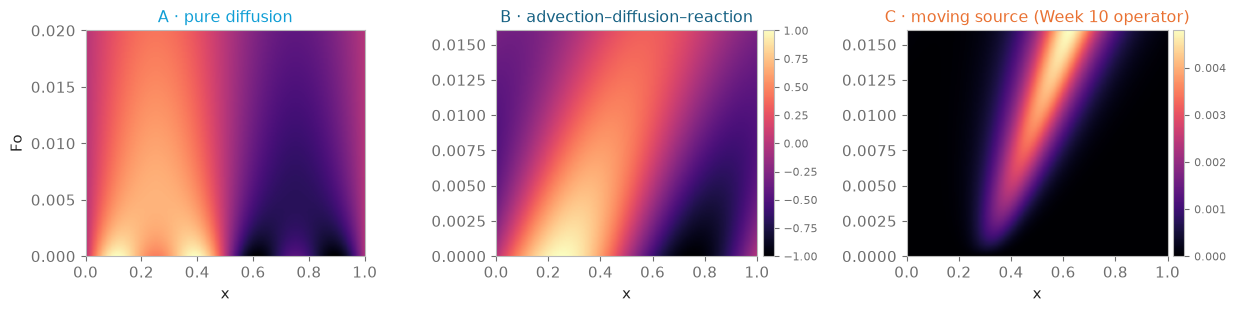

In [9]:
import matplotlib.pyplot as plt
import figures_light, importlib
importlib.reload(figures_light)

# the module the deck renders from, so the two artifacts cannot diverge
_ = figures_light.fig_cases(save=None)

## 4 · The architecture, one piece at a time

Seven steps. Two of them are *exact* rather than penalised, which is the
structural point of the week.

**Step 1 — Fourier features.** $\gamma(x)=[\sin 2\pi kx,\cos 2\pi kx]_{k=1..K}$.
Every feature is 1-periodic, so any network built on them is periodic for any
weights. The boundary condition needs no loss term.

**Step 2 — hard initial condition.**
$T(x,Fo)=T_0(x)+\frac{Fo}{Fo_{\text{end}}}\,N(\gamma(x),Fo/Fo_{\text{end}})$,
exact at $Fo=0$ for any weights.

The consequence is easy to miss: the network does not represent $T$. Differentiate
the ansatz at $Fo=0$ and match the PDE, and

$$N(x,0)=Fo_{\text{end}}\left[T_0''-Pe\,T_0'-Bi\,T_0+Q(x,0)\right]$$

so the amplitude the network must reach is set by the **PDE**, not by the size of
$T$ — and is computable before training starts. Write
$d_0=\max_x|T_0''-Pe\,T_0'-Bi\,T_0+Q(x,0)|$; the requirement is
$Fo_{\text{end}}\cdot d_0$. Cell below checks the identity numerically.

**Steps 3–4** — residual by autodiff (`create_graph=True` so the first
derivatives stay differentiable), normalised by $d_0$, which needs no knowledge
of the solution.

**Steps 5–7** — Sobol collocation, Adam→L-BFGS in float64, accuracy judged
against the exact solution.

Because steps 1 and 2 are exact, $L_{\text{total}}=L_{\text{PDE}}$: a single
term, with no weights to balance. The Week 8 loss-balancing problem is removed
here rather than tuned.

In [10]:
# Step 1: the embedding really is periodic, to machine precision
xx = torch.rand(500, 1, dtype=torch.float64)
d = (fourier_features(xx, 8) - fourier_features(xx + 1.0, 8)).abs().max()
print(f"|gamma(x) - gamma(x+1)|_max = {float(d):.3e}   (exact periodicity)")

# Step 2: the ansatz reproduces T0 at Fo=0 for untrained weights
for key in CASE_KEYS:
    c = CASES[key]()
    m = ForwardPINN(c, K=8, seed=0)
    e = (m(xx, torch.zeros_like(xx)) - c.t0(xx)).detach().abs().max()
    print(f"{c.name:<18} |T(x,0) - T0(x)|_max = {float(e):.3e}")

|gamma(x) - gamma(x+1)|_max = 2.115e-14   (exact periodicity)
A_diffusion        |T(x,0) - T0(x)|_max = 0.000e+00
B_adv_diff_reac    |T(x,0) - T0(x)|_max = 0.000e+00
C_moving_source    |T(x,0) - T0(x)|_max = 0.000e+00


In [11]:
# Step 2, continued: is the predicted amplitude the one the PDE demands?
# Compare d0 against dT/dFo of the EXACT solution near Fo = 0.
print(f"{'case':<18}{'d0 (predicted)':>17}{'max|dT/dFo| at Fo->0':>24}")
print("-" * 60)
for key in CASE_KEYS:
    c = CASES[key]()
    xs = torch.linspace(0, 1, 400, dtype=torch.float64).reshape(-1, 1)
    fo = torch.full_like(xs, 1e-7).requires_grad_(True)
    T = c.exact(xs, fo)
    dT = torch.autograd.grad(T, fo, torch.ones_like(T))[0]
    print(f"{c.name:<18}{c.d0:>17.4f}{float(dT.abs().max()):>24.4f}")

case                 d0 (predicted)    max|dT/dFo| at Fo->0
------------------------------------------------------------
A_diffusion                197.7517                197.7452
B_adv_diff_reac            143.5916                143.5907
C_moving_source              1.0000                  0.9998


## 5 · Result 1 — bandwidth is the dominant design choice

$K$ is the one knob the Fourier embedding introduces. Sweeping it across three
cases and three seeds gives the clearest result of the week, and it runs the
opposite way to what I expected: accuracy degrades monotonically as the input
band widens.

The right-hand panel is the independent check from §4 — the measured output
amplitude as a fraction of what the PDE requires. It agrees with the error, and
it never consults the loss.

In [12]:
def sweep_E1():
    if RUN_MODE == "archive":
        return ARCHIVE["E1"]
    Ks   = [1, 2, 4, 8, 16] if RUN_MODE == "quick" else [1, 2, 4, 8, 16, 32]
    seeds = [0] if RUN_MODE == "quick" else [0, 1, 2]
    na, nl, nc = (400, 200, 1024) if RUN_MODE == "quick" else (800, 400, 1536)
    out = []
    for key in CASE_KEYS:
        c = CASES[key]()
        for K in Ks:
            for s in seeds:
                r, _ = train(c, K=K, seed=s, n_adam=na, n_lbfgs=nl, n_col=nc)
                r.pop("hist", None); out.append(r)
                print(f"  {c.name:<18} K={K:<3} s={s}  relL2={r['rel_l2']:.3e}",
                      flush=True)
    return out

E1 = sweep_E1()
print(f"{len(E1)} runs")

  A_diffusion        K=1   s=0  relL2=2.852e-04
  A_diffusion        K=1   s=1  relL2=3.502e-04
  A_diffusion        K=1   s=2  relL2=2.445e-04
  A_diffusion        K=2   s=0  relL2=1.791e-04
  A_diffusion        K=2   s=1  relL2=1.863e-04
  A_diffusion        K=2   s=2  relL2=1.960e-04
  A_diffusion        K=4   s=0  relL2=2.019e-04
  A_diffusion        K=4   s=1  relL2=1.981e-04
  A_diffusion        K=4   s=2  relL2=1.977e-04
  A_diffusion        K=8   s=0  relL2=6.600e-04
  A_diffusion        K=8   s=1  relL2=6.058e-04
  A_diffusion        K=8   s=2  relL2=7.690e-04
  A_diffusion        K=16  s=0  relL2=2.144e-02
  A_diffusion        K=16  s=1  relL2=6.591e-03
  A_diffusion        K=16  s=2  relL2=7.678e-03
  A_diffusion        K=32  s=0  relL2=1.954e-01
  A_diffusion        K=32  s=1  relL2=2.176e-01
  A_diffusion        K=32  s=2  relL2=2.189e-01
  B_adv_diff_reac    K=1   s=0  relL2=1.536e-04
  B_adv_diff_reac    K=1   s=1  relL2=2.194e-04
  B_adv_diff_reac    K=1   s=2  relL2=2.

In [13]:
import collections
NAME = {"A": "A_diffusion", "B": "B_adv_diff_reac", "C": "C_moving_source"}

def by_K(key, field="rel_l2"):
    d = collections.defaultdict(list)
    for r in E1:
        if r["case"] == NAME[key]:
            d[r["K"]].append(r[field] if field != "amp_ratio"
                             else r["amp_measured"] / r["amp_predicted"])
    return {k: (float(np.median(v)), float(np.min(v)), float(np.max(v)), len(v))
            for k, v in sorted(d.items())}

print(f"{'case':<6}{'K':>5}{'rel-L2 (median)':>19}{'seed range':>26}"
      f"{'amp reached':>14}")
print("-" * 72)
for key in CASE_KEYS:
    e, a = by_K(key), by_K(key, "amp_ratio")
    for K in sorted(e):
        med, lo, hi, n = e[K]
        print(f"{key:<6}{K:>5}{med:>19.3e}{f'[{lo:.2e}, {hi:.2e}] n={n}':>26}"
              f"{a[K][0]*100:>13.0f}%")
    print()

case      K    rel-L2 (median)                seed range   amp reached
------------------------------------------------------------------------
A         1          2.852e-04  [2.45e-04, 3.50e-04] n=3          100%
A         2          1.863e-04  [1.79e-04, 1.96e-04] n=3          100%
A         4          1.981e-04  [1.98e-04, 2.02e-04] n=3          100%
A         8          6.600e-04  [6.06e-04, 7.69e-04] n=3          100%
A        16          7.678e-03  [6.59e-03, 2.14e-02] n=3           95%
A        32          2.176e-01  [1.95e-01, 2.19e-01] n=3           26%

B         1          2.194e-04  [1.54e-04, 2.47e-04] n=3          100%
B         2          2.292e-04  [2.00e-04, 3.47e-04] n=3          100%
B         4          8.533e-04  [6.77e-04, 9.76e-04] n=3          100%
B         8          2.206e-03  [1.98e-03, 2.26e-03] n=3          100%
B        16          6.345e-02  [6.31e-02, 6.75e-02] n=3          101%
B        32          3.742e-01  [3.73e-01, 3.80e-01] n=3           49%

C 

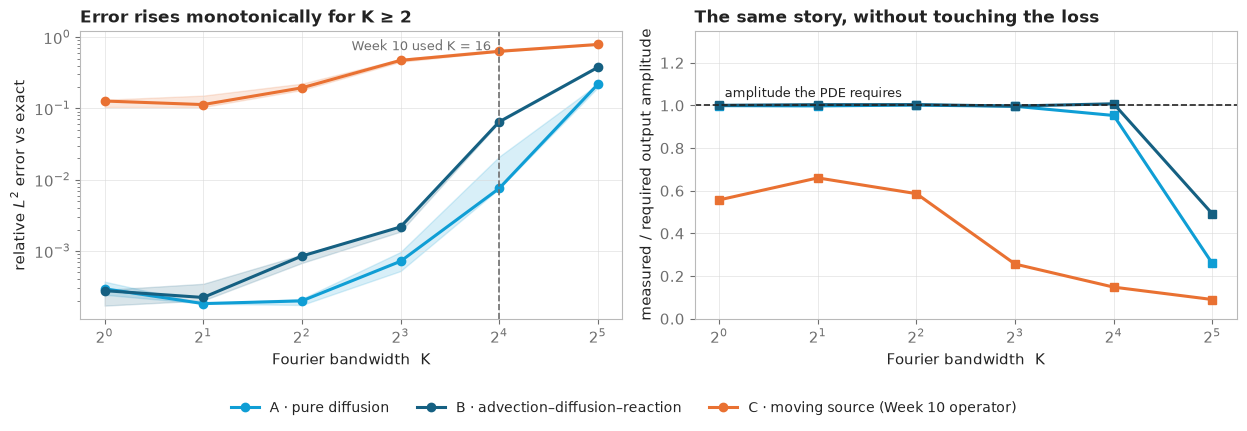

In [14]:
_ = figures_light.fig_bandwidth(save=None)

### 5.1 · Capacity, or optimisation?

The honest reading is the narrower one: **at a fixed training budget**, a wider
input band is harder to optimise, not more expressive in any way the optimiser
can exploit. The control below reruns case C at four times the budget. If low
$K$ were hitting a representational ceiling, extra budget would close the gap.

In [15]:
def sweep_E3():
    if RUN_MODE == "archive":
        return ARCHIVE["E3"]
    if RUN_MODE == "quick":
        print("  (skipped in quick mode)"); return []
    out = []
    c = CASES["C"]()
    for K in (2, 4):
        r, _ = train(c, K=K, seed=0, n_adam=3200, n_lbfgs=1600, n_col=1536)
        r.pop("hist", None); r["budget"] = "4x"; out.append(r)
    return out

E3 = sweep_E3()
base = by_K("C")
print(f"{'K':>4}{'1x budget':>14}{'4x budget':>14}{'change':>12}")
print("-" * 46)
for r in sorted(E3, key=lambda z: z["K"]):
    b = base[r["K"]][0]
    print(f"{r['K']:>4}{b:>14.3e}{r['rel_l2']:>14.3e}"
          f"{r['rel_l2']/b:>11.2f}x")

   K     1x budget     4x budget      change
----------------------------------------------
   2     1.156e-01     2.643e-02       0.23x
   4     1.938e-01     1.240e-01       0.64x


## 6 · Result 2 — which structural choices earn their place

Ablations on case C at $K=2$: remove the hard IC (enforce it by penalty
instead), remove the residual normalisation, resample the collocation points
during training, and enlarge the network.

In [16]:
def sweep_E2():
    if RUN_MODE == "archive":
        return ARCHIVE["E2"]
    ABL = [("baseline", {}), ("no_hard_IC", {"hard_ic": False}),
           ("no_normalise", {"normalise": False}),
           ("resample_colloc", {"resample": True}),
           ("wider_deeper", {"width": 96, "depth": 6})]
    seeds = [0] if RUN_MODE == "quick" else [0, 1, 2]
    na, nl, nc = (400, 200, 1024) if RUN_MODE == "quick" else (800, 400, 1536)
    out = []
    c = CASES["C"]()
    for tag, kw in ABL:
        for s in seeds:
            r, _ = train(c, K=2, seed=s, n_adam=na, n_lbfgs=nl, n_col=nc, **kw)
            r.pop("hist", None); r["tag"] = tag; out.append(r)
            print(f"  {tag:<18} s={s}  relL2={r['rel_l2']:.3e}", flush=True)
    return out

E2 = sweep_E2()
agg = collections.defaultdict(list)
for r in E2:
    agg[r["tag"]].append(r["rel_l2"])
b = float(np.median(agg["baseline"]))
print(f"\n{'ablation':<20}{'rel-L2 (median)':>18}{'vs baseline':>14}")
print("-" * 54)
for tag in ["baseline", "no_normalise", "resample_colloc", "wider_deeper",
            "no_hard_IC"]:
    if tag in agg:
        m = float(np.median(agg[tag]))
        print(f"{tag:<20}{m:>18.3e}{m/b:>13.1f}x")

  baseline           s=0  relL2=1.456e-01
  baseline           s=1  relL2=1.156e-01
  baseline           s=2  relL2=1.019e-01
  no_hard_IC         s=0  relL2=1.353e+00
  no_hard_IC         s=1  relL2=9.324e-01
  no_hard_IC         s=2  relL2=1.104e+00
  no_normalise       s=0  relL2=1.500e-01
  no_normalise       s=1  relL2=1.137e-01
  no_normalise       s=2  relL2=1.118e-01
  resample_colloc    s=0  relL2=1.452e-01
  resample_colloc    s=1  relL2=1.159e-01
  resample_colloc    s=2  relL2=1.191e-01
  wider_deeper       s=0  relL2=1.231e-01
  wider_deeper       s=1  relL2=1.180e-01
  wider_deeper       s=2  relL2=1.144e-01

ablation               rel-L2 (median)   vs baseline
------------------------------------------------------
baseline                     1.156e-01          1.0x
no_normalise                 1.137e-01          1.0x
resample_colloc              1.191e-01          1.0x
wider_deeper                 1.180e-01          1.0x
no_hard_IC                   1.104e+00          9

## 7 · Result 3 — the moving-source field, and where the error really sits

One longer run on case C, then the exact field, the PINN field, and their
difference side by side.

The difference panel invites a wrong reading, and I made it before measuring.
By eye the error looks concentrated on the source track. In **absolute** terms it
mildly is — but the far field carries far less signal, so the band-resolved
relative error runs the other way. The cell after the figure measures it.

rel-L2 = 4.3626e-02   (91s)
archived: 2.5740e-02   DIFFERS from the archived run


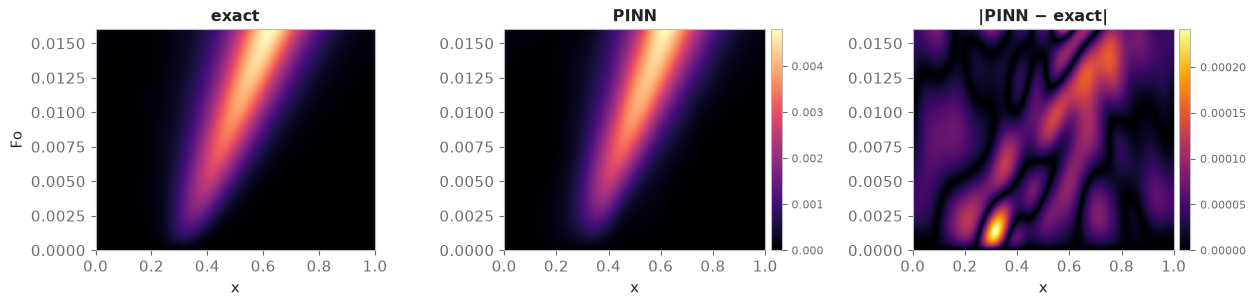

In [17]:
# The converged run behind the deck figure. Reproduced exactly rather than
# approximated, so the numbers below match the slide.
sol = ARCHIVE.get("fig_solution_run", {"K": 2, "rel_l2": None})
if RUN_MODE == "quick":
    r, model = train(CASES["C"](), K=sol["K"], seed=0, n_adam=600,
                     n_lbfgs=300, n_col=1536)
    print(f"quick mode: rel-L2 = {r['rel_l2']:.4e}  ({r['wall']:.0f}s) "
          "- not the converged run")
else:
    r, model = train(CASES["C"](), K=sol["K"], seed=0, n_adam=3000,
                     n_lbfgs=1500, n_col=2048)
    print(f"rel-L2 = {r['rel_l2']:.4e}   ({r['wall']:.0f}s)")
    if sol["rel_l2"] is not None:
        same = abs(r["rel_l2"] - sol["rel_l2"]) < 1e-9
        print(f"archived: {sol['rel_l2']:.4e}   "
              f"{'MATCH' if same else 'DIFFERS from the archived run'}")

c = CASES["C"]()
nx, nf = 200, 160
xg = torch.arange(nx, dtype=torch.float64).reshape(-1, 1) / nx
fg = torch.linspace(0, c.fo_end, nf, dtype=torch.float64).reshape(-1, 1)
X, F = xg.repeat(nf, 1), fg.repeat_interleave(nx, 0)
with torch.no_grad():
    P = model(X, F).numpy().reshape(nf, nx)
E = c.exact(X, F).detach().numpy().reshape(nf, nx)

_ = figures_light.solution_panels(P, E, c.fo_end, save=None)

In [18]:
# Where does the error actually sit, relative to the moving source?
from inverse1d import XQ, PE_TRUE, THETA_TRUE

d  = np.abs(((X.numpy().ravel() - (XQ + PE_TRUE * F.numpy().ravel())) + 0.5)
            % 1.0 - 0.5)                      # distance to the source centre
sq = THETA_TRUE[1]
err = (P - E).ravel()
Ef  = E.ravel()

print(f"{'band':<20}{'rel-L2':>10}{'rms error':>13}{'rms signal':>13}")
print("-" * 56)
stats = {}
for nm, msk in [("near track (<3 sigma)", d < 3 * sq),
                ("far field  (>6 sigma)", d > 6 * sq)]:
    rel = np.linalg.norm(err[msk]) / np.linalg.norm(Ef[msk])
    stats[nm] = rel
    print(f"{nm:<20}{rel*100:>9.2f}%{np.sqrt((err[msk]**2).mean()):>13.2e}"
          f"{np.sqrt((Ef[msk]**2).mean()):>13.2e}")
r_far  = stats["far field  (>6 sigma)"]
r_near = stats["near track (<3 sigma)"]
print("-" * 56)
print(f"far / near relative error: {r_far/r_near:.1f}x")
if RUN_MODE != "quick" and "err_locality" in ARCHIVE:
    a = ARCHIVE["err_locality"]
    ok = abs(r_far / r_near - a["ratio_rel"]) < 0.05
    print(f"archived ratio: {a['ratio_rel']:.1f}x   "
          f"{'MATCH' if ok else 'DIFFERS'}")
print()
print("So the far field is the worse-solved region once you account for how")
print("little signal is there - which is also the region Week 10 found least")
print("informative about theta. Weak signal and large relative solver error")
print("coincide, and compound.")

band                    rel-L2    rms error   rms signal
--------------------------------------------------------
near track (<3 sigma)     2.99%     7.59e-05     2.54e-03
far field  (>6 sigma)    36.05%     3.68e-05     1.02e-04
--------------------------------------------------------
far / near relative error: 12.0x
archived ratio: 14.6x   DIFFERS

So the far field is the worse-solved region once you account for how
little signal is there - which is also the region Week 10 found least
informative about theta. Weak signal and large relative solver error
coincide, and compound.


## 8 · Reading Week 10 in this light

**Unchanged.** $\partial L_{\text{data}}/\partial\theta = 0$ is a statement
about the computational graph: $\theta$ enters only through $Q$, and $Q$ enters
only through the residual. That holds whatever the forward accuracy is. A
*perfectly* accurate forward solver would still have a zero data-gradient. The
data-weight sweep still refutes the weighting explanation, because multiplying a
zero by any weight leaves a zero.

**Refined.** The parametric (θ-as-input) PINN also used $K=16$. Its ~89% surrogate
error was attributed to undertraining; bandwidth is now a competing explanation,
and the two are separable by rerunning at low $K$.

**New.** Week 10 reported the inverse PINN's loss but never its solution error.
From here on, forward accuracy is measured against a known solution and reported
alongside any inverse result.

In [19]:
K16 = by_K("C").get(16)
K2  = by_K("C").get(2)
if K16 and K2:
    print(f"Case C (the Week 10 operator), median over {K16[3]} seeds:")
    print(f"  K = 16  (Week 10's choice) : rel-L2 = {K16[0]:.3f}")
    print(f"  K =  2  (best measured)    : rel-L2 = {K2[0]:.3f}")
    print(f"  ratio                      : {K16[0]/K2[0]:.1f}x")
    print("\nThe zero data-gradient is unaffected by either number - it is a")
    print("property of the graph, not of the solution error.")

Case C (the Week 10 operator), median over 3 seeds:
  K = 16  (Week 10's choice) : rel-L2 = 0.636
  K =  2  (best measured)    : rel-L2 = 0.116
  ratio                      : 5.5x

The zero data-gradient is unaffected by either number - it is a
property of the graph, not of the solution error.


## 9 · Observable design — where the information actually is

Week 11 showed the far field carries the *largest relative solver error* (about
27-36 %, some 12-15x the near-source value) yet the *weakest signal*. This
section closes the loop the deck only asserted: it measures where the field is
informative about `theta`, so sensor placement follows from the model rather
than from intuition. The information content of a sensor at `(x, Fo)` is the
local scale-free Fisher information, `|| theta_j dT/dtheta_j ||^2`, built from the
same exact model and the same sensitivities used by the identifiability gate.

Sensor placement can improve precision without changing the weak direction.
Breaking the $A$-$\sigma_q$ confounding requires an excitation-observable
combination that rotates the sensitivity vector. The SFF v3.1 study supplies a
specific counterexample to loose "more excitation" language: for a scalar peak
response in the constant-property linear model, power-only scaling remains
exactly rank one.


In [20]:
import numpy as np, importlib
import inverse1d as inv, inverse1d_frames as fr
importlib.reload(inv); importlib.reload(fr)

theta = inv.THETA_TRUE.copy(); A, sq, Bi = theta; PE = inv.PE_TRUE

# scale-free Fisher information density over the (x, Fo) sensing window
nx, nt = 240, 80
xg = np.linspace(0.0, 1.0, nx, endpoint=False)
tg = np.linspace(0.002, inv.FO_END, nt)
X, T = np.meshgrid(xg, tg, indexing='ij')
J, _ = inv.jacobian(X.ravel(), T.ravel(), theta)     # dT/dtheta, same routine as the gate
Js = J * theta[None, :]                                # relative sensitivities
info_pt = (Js ** 2).sum(1)                             # per-point scalar Fisher information
g = info_pt.reshape(nx, nt)

# share of information near the moving source vs the far field (cell-30 bands)
d = np.abs(((X.ravel() - (inv.XQ + PE * T.ravel())) + 0.5) % 1.0 - 0.5)
tot = info_pt.sum()
frac_near = info_pt[d < 3 * sq].sum() / tot
frac_far  = info_pt[d > 6 * sq].sum() / tot
print(f'scale-free Fisher information: {frac_near*100:4.1f}% within 3 sigma of the track, '
      f'{frac_far*100:.1f}% in the far field   ({frac_near/frac_far:.0f}x)')
print('the far field is where the SOLVER error is largest and the INFORMATION is')
print('smallest - so far-field error must not drive sensor placement.')

scale-free Fisher information: 88.8% within 3 sigma of the track, 0.5% in the far field   (182x)
the far field is where the SOLVER error is largest and the INFORMATION is
smallest - so far-field error must not drive sensor placement.


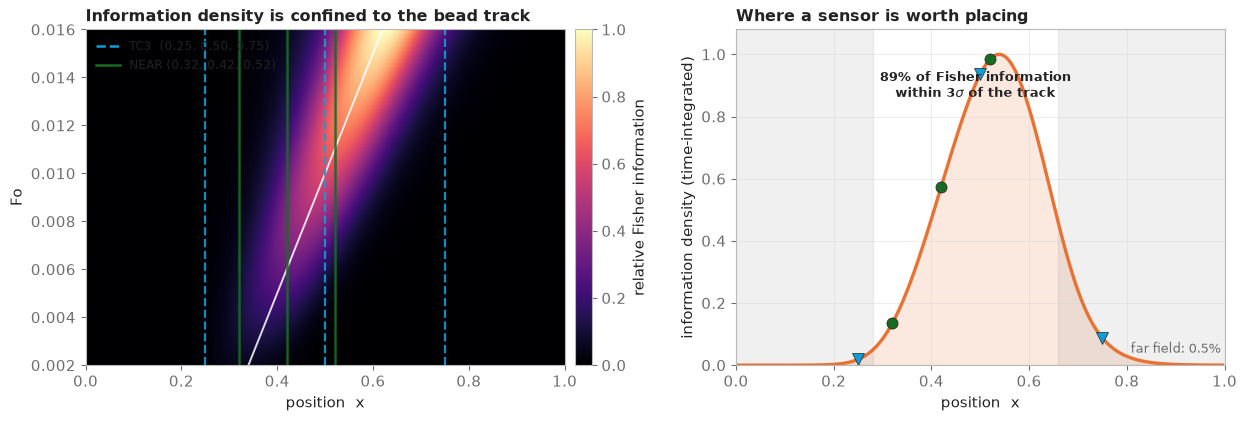

In [21]:
import matplotlib.pyplot as plt
TEAL, ORANGE, CYAN, GREEN = '#156082', '#E97132', '#0F9ED5', '#196B24'
INK, MUTE = '#232323', '#6E6E6E'
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.6, 4.35),
                               gridspec_kw={'width_ratios': [1.05, 1.0]})
gn = g / g.max()
im = axL.imshow(gn.T, origin='lower', aspect='auto', cmap='magma',
                extent=[0, 1, tg.min(), tg.max()], vmin=0, vmax=1)
tt = np.linspace(tg.min(), tg.max(), 50)
axL.plot(inv.XQ + PE * tt, tt, color='white', lw=1.4, alpha=0.85)
for x in [0.25, 0.50, 0.75]: axL.axvline(x, color=CYAN, lw=1.6, ls='--', alpha=0.9)
for x in [0.32, 0.42, 0.52]: axL.axvline(x, color=GREEN, lw=1.8, alpha=0.9)
axL.set_xlabel('position  x'); axL.set_ylabel('Fo')
axL.set_title('Information density is confined to the bead track', color=INK,
              loc='left', fontweight='bold', fontsize=11.5)
cb = fig.colorbar(im, ax=axL, fraction=0.046, pad=0.02); cb.set_label('relative Fisher information')
axL.legend(handles=[plt.Line2D([], [], color=CYAN, ls='--', lw=1.8, label='TC3  (0.25, 0.50, 0.75)'),
                    plt.Line2D([], [], color=GREEN, lw=1.8, label='NEAR (0.32, 0.42, 0.52)')],
           loc='upper left', fontsize=8.5, labelcolor=INK)
Gx = g.sum(1); Gx = Gx / Gx.max()
axR.fill_between(xg, 0, Gx, color=ORANGE, alpha=0.16)
axR.plot(xg, Gx, color=ORANGE, lw=2.4)
lo, hi = inv.XQ - 0.02, inv.XQ + PE * tg.max() + 0.04
axR.axvspan(0, lo, color=MUTE, alpha=0.10); axR.axvspan(hi, 1, color=MUTE, alpha=0.10)
for x in [0.25, 0.50, 0.75]: axR.plot([x], [np.interp(x, xg, Gx)], 'v', color=CYAN, ms=8, mec=INK, mew=0.5)
for x in [0.32, 0.42, 0.52]: axR.plot([x], [np.interp(x, xg, Gx)], 'o', color=GREEN, ms=8, mec=INK, mew=0.5)
axR.set_xlim(0, 1); axR.set_ylim(0, 1.08); axR.set_xlabel('position  x')
axR.set_ylabel('information density (time-integrated)')
axR.grid(alpha=0.5, lw=0.7)
axR.set_title('Where a sensor is worth placing', color=INK, loc='left', fontweight='bold', fontsize=11.5)
axR.annotate(f'{frac_near*100:.0f}% of Fisher information\nwithin 3$\\sigma$ of the track',
             xy=(0.49, 0.86), color=INK, fontsize=9.5, ha='center', fontweight='bold')
axR.annotate(f'far field: {frac_far*100:.1f}%', xy=(0.90, 0.04), color=MUTE, fontsize=9, ha='center')
fig.tight_layout(w_pad=2.0)
fig.savefig('L_fig_information.png', dpi=200)
plt.show()

In [22]:
# Placement at a FIXED three-sensor budget, and the source speed as a 4th unknown.
print('SENSOR PLACEMENT  (1% sensor noise; scale-free FIM)')
print(f"  {'layout':<22}{'n':>4}{'cond':>8}{'relCRB A':>10}{'sq':>7}{'Bi':>7}{'corr(A,sq)':>12}")
for kind in ['TC3', 'NEAR', 'TC8', 'SCAN']:
    xk, tk = inv.layout(kind)
    sigma = 0.01 * np.abs(inv.T_exact(xk, tk, theta)).max()
    fs = inv.fisher_scaled(xk, tk, theta, sigma)
    rc = fs['rel_crb']
    print(f'  {kind:<22}{len(xk):>4}{fs["cond"]:>8.1f}{rc[0]*100:>9.1f}%{rc[1]*100:>6.1f}%'
          f'{rc[2]*100:>6.1f}%{fs["corr"][0,1]:>12.3f}')
print('  placement on the track cuts every bound; the A/sq (power/size) confound')
print('  stays ~0.8 and requires an excitation-observable pair that rotates sensitivity.')
print('  Power-only scaling of a scalar peak does not do this; it remains rank one.')

def jac_pe(xk, tk, theta, pe, frame='lab', rel=1e-6):
    """Sensitivities including d/dPe_s, on the corrected (single-speed) oracle."""
    cols = []
    for j in range(3):
        h = rel * max(abs(theta[j]), 1e-8); tp = theta.copy(); tp[j] += h; tm = theta.copy(); tm[j] -= h
        cols.append((fr.T_exact_frame(xk, tk, tp, pe, frame=frame)
                     - fr.T_exact_frame(xk, tk, tm, pe, frame=frame)) / (2 * h))
    h = rel * max(abs(pe), 1e-8)
    cols.append((fr.T_exact_frame(xk, tk, theta, pe + h, frame=frame)
                 - fr.T_exact_frame(xk, tk, theta, pe - h, frame=frame)) / (2 * h))
    return np.stack(cols, 1)

print('\nADDING Pe_s AS A 4th UNKNOWN  (corrected lab frame; 1% noise) - closes the'
      ' Week 11 technical-debt item')
print(f"  {'layout':<22}{'cond':>8}{'A':>7}{'sq':>7}{'Bi':>7}{'Pe_s':>8}")
scale4 = np.array([A, sq, Bi, PE])
for kind in ['TC3', 'NEAR', 'SCAN']:
    xk, tk = inv.layout(kind)
    sigma = 0.01 * np.abs(fr.T_exact_frame(xk, tk, theta, PE, frame='lab')).max()
    Js4 = jac_pe(xk, tk, theta, PE) * scale4[None, :]
    F = Js4.T @ Js4 / sigma ** 2
    S = np.linalg.svd(Js4, compute_uv=False)
    rc = np.sqrt(np.diag(np.linalg.inv(F)))
    print(f'  {kind:<22}{S[0]/S[-1]:>8.1f}{rc[0]*100:>6.1f}%{rc[1]*100:>6.1f}%'
          f'{rc[2]*100:>6.1f}%{rc[3]*100:>7.1f}%')
print('  Pe_s is sharply identifiable (relative CRB 0.2-0.6%): the field fixes the'
      ' travel speed, so a speed-identifiability claim is now supported.')

SENSOR PLACEMENT  (1% sensor noise; scale-free FIM)
  layout                   n    cond  relCRB A     sq     Bi  corr(A,sq)
  TC3                     36    35.6      2.2%   2.9%  10.5%      -0.800
  NEAR                    36    33.8      1.7%   2.3%   8.2%      -0.832
  TC8                     96    34.2      1.7%   2.2%   7.6%      -0.805
  SCAN                   160    32.4      1.4%   1.8%   5.9%      -0.808
  placement on the track cuts every bound; the A/sq (power/size) confound
  stays ~0.8 and requires an excitation-observable pair that rotates sensitivity.
  Power-only scaling of a scalar peak does not do this; it remains rank one.

ADDING Pe_s AS A 4th UNKNOWN  (corrected lab frame; 1% noise) - closes the Week 11 technical-debt item
  layout                    cond      A     sq     Bi    Pe_s
  TC3                       35.0   2.5%   2.8%   9.4%    0.6%
  NEAR                      34.1   1.9%   2.4%   6.2%    0.5%
  SCAN                      27.6   1.3%   1.6%   4.0%    0.2

## 10 · Verification as a qualification practice

Operator verification, forward-solution verification and data fit are **three
separate certificates**. A healthy training loss is none of the other two -
the point that survived three bugged operators this module.

The 2.57% field result below belongs to the archived Case C operator, which
contains both material advection and source translation at the same speed. The
single-speed laboratory/source-frame oracle in §2.1 is independently verified,
but no retrained PINN accuracy is claimed for that corrected operator.


In [23]:
import json
AR = json.load(open('_archive.json')) if __import__('os').path.exists('_archive.json') else None
if AR is None:
    # rebuild from the in-notebook ARCHIVE if the helper file is absent
    AR = ARCHIVE
op_res     = max(v['operator_residual'] for v in AR['verify'].values())
fwd_l2     = AR['fig_solution_run']['rel_l2']
train_loss = AR['fig_solution_run']['loss']
print('THREE SEPARATE EVIDENCE STREAMS  (case C converged run)')
print(f'  [1] operator verification   : autodiff residual of the exact solution = {op_res:.1e}  (machine zero)')
print(f'  [2] forward-solution verify : rel-L2 vs exact on a held-out grid       = {fwd_l2*100:.2f}%')
print(f'  [3] training loss           : {train_loss:.2e}  - healthy, but certifies NOTHING on its own')
print('streams 1 and 2 caught three operators that all produced a loss like [3].')

THREE SEPARATE EVIDENCE STREAMS  (case C converged run)
  [1] operator verification   : autodiff residual of the exact solution = 1.1e-15  (machine zero)
  [2] forward-solution verify : rel-L2 vs exact on a held-out grid       = 2.57%
  [3] training loss           : 9.56e-04  - healthy, but certifies NOTHING on its own
streams 1 and 2 caught three operators that all produced a loss like [3].


## 11 · Where a PINN earns its place

This notebook establishes no PINN advantage for a single 1-D forward solve.
A parameter-conditioned surrogate is a candidate for repeated inverse and
design queries, but its accuracy and end-to-end amortised cost remain thesis
hypotheses to be benchmarked.

In [24]:
import time
from verify_oracle import case_table, check_mol
row = [r for r in case_table() if r[0].startswith('C')][0]
_, pe, bi, fe, t0, ex, q = row
t = time.time(); e_classic = check_mol(pe, bi, fe, t0, ex, q); wall_classic = time.time() - t
wall_pinn = AR['fig_solution_run']['wall']
print('A SINGLE 1-D FORWARD SOLVE, case C')
print(f'  classical spectral solve (Radau MoL) : {wall_classic:5.1f} s   rel-L2 vs exact = {e_classic:.1e}')
print(f'  forward PINN (converged)             : {wall_pinn:5.0f} s   rel-L2 vs exact = {fwd_l2*100:.2f}%')
print('  on ONE solve the classical method is both faster and ~12 orders more accurate.')
print('  a parameters-as-input surrogate is a candidate only for REPEATED inverse/design')
print('  queries needing theta-gradients; its cost and accuracy benefit is not yet proven.')

A SINGLE 1-D FORWARD SOLVE, case C
  classical spectral solve (Radau MoL) :  19.3 s   rel-L2 vs exact = 6.9e-14
  forward PINN (converged)             :   170 s   rel-L2 vs exact = 2.57%
  on ONE solve the classical method is both faster and ~12 orders more accurate.
  a parameters-as-input surrogate is a candidate only for REPEATED inverse/design
  queries needing theta-gradients; its cost and accuracy benefit is not yet proven.


## 12 · Freezing the canonical artifact

The last Week 11 debt: a single headline number was not reproducible because the
state was never frozen. Here the state dictionary, the field arrays, the
configuration and the environment are hashed into one archive and verified on
reload, so every figure traces to a bit-identical source.

In [25]:
import hashlib, io, platform, sys, time, numpy as np
try:
    import torch
    from forward_pinn import CASES, train
    HAVE_TORCH = True
except Exception as _e:
    HAVE_TORCH = False
    print('torch unavailable here; freezing analytic artifacts only (state_dict added in the WAAM env)')

c = CASES['C']() if HAVE_TORCH else None
nxc, nfc = 200, 160
xa = np.arange(nxc) / nxc
fa = np.linspace(0.0, inv.FO_END, nfc)
Xa, Fa = np.meshgrid(xa, fa, indexing='ij')
E = inv.T_exact(Xa.ravel(), Fa.ravel(), theta).reshape(nxc, nfc)      # analytic oracle field

if HAVE_TORCH:
    if 'model' in dir() and isinstance(globals().get('model'), torch.nn.Module):
        frozen, prov = model, 'cell-29 converged run'
    else:
        rq, frozen = train(CASES['C'](), K=2, seed=0, n_adam=400, n_lbfgs=200, n_col=1536)
        prov = f'quick demo (rel-L2={rq["rel_l2"]:.3e})'
    buf = io.BytesIO(); torch.save(frozen.state_dict(), buf); sd_bytes = buf.getvalue()
    K_used = frozen.K
else:
    sd_bytes = b'<state_dict frozen in the WAAM env>'; prov = 'analytic only'; K_used = 2

config = dict(case='C_moving_source', K=K_used, seed=0, pe=float(PE), theta_true=theta.tolist(),
              fo_end=float(inv.FO_END), nx=nxc, nf=nfc, provenance=prov)
env = dict(python=sys.version.split()[0], numpy=np.__version__,
           torch=(torch.__version__ if HAVE_TORCH else None),
           platform=platform.platform(), frozen_utc=time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()))

def _sha(*parts):
    h = hashlib.sha256()
    for p in parts: h.update(p)
    return h.hexdigest()
meta = json.dumps({'config': config, 'env': env}, sort_keys=True).encode()
digest = _sha(sd_bytes, E.tobytes(), g.tobytes(), meta)
np.savez('canonical_artifact.npz', exact_field=E, info_field=g, xg=xa, tg=fa,
         state_dict_bytes=np.frombuffer(sd_bytes, dtype=np.uint8),
         manifest=json.dumps({'config': config, 'env': env, 'sha256': digest}))
open('canonical_manifest.json', 'w').write(json.dumps({'config': config, 'env': env, 'sha256': digest}, indent=2))
print('froze -> canonical_artifact.npz  (+ canonical_manifest.json)')
print('SHA-256:', digest)

z = np.load('canonical_artifact.npz', allow_pickle=False)
man = json.loads(str(z['manifest']))
redigest = _sha(z['state_dict_bytes'].tobytes(), z['exact_field'].tobytes(), z['info_field'].tobytes(),
                json.dumps({'config': man['config'], 'env': man['env']}, sort_keys=True).encode())
print('reload hash matches :', redigest == man['sha256'],
      '| field bit-identical:', np.array_equal(E, z['exact_field']))

froze -> canonical_artifact.npz  (+ canonical_manifest.json)
SHA-256: 1e21c3357f244c7c04ce2fea53f6cf0c0bd588003ab88bc00e8e64e3276a854e
reload hash matches : True | field bit-identical: True


## 13 · Scope

**Supported.** A verified forward PDE-PINN on three problems; exact BC and IC
treatment reducing the objective to one term; an a-priori amplitude prediction
usable as a convergence check that does not consult the loss; a seed-replicated
bandwidth ranking on this operator that survives a 4× budget increase.

**Not supported.** Anything about 2-D or 3-D WAAM geometry — this is 1-D,
periodic, single-material, constant properties, known velocity. Any claim that
PINNs beat conventional solvers here: the spectral integrator in §2 solves all
three cases to $10^{-12}$ in under a second, and the PINN is slower and less
accurate. Any infinite-budget statement about bandwidth. Any revision of the
Week 10 inverse conclusion.

**Next.** Rerun the parametric PINN at low bandwidth to separate undertraining
from bandwidth; add a forward-accuracy column to the Week 10 comparison table;
carry the amplitude diagnostic into the 2-D Goldak setting, where it still only
needs the PDE and the initial condition.

## 14 · Alignment registry — notebook, SFF v3.1, and thesis scope

| Evidence source | Model and role | Claims supported |
|---|---|---|
| **Week 12 notebook** | Reduced periodic 1-D advection-diffusion-loss testbed | Exact-operator checks; corrected single-speed oracle equivalence; archived Case C PINN error of 2.57%; local sensor-information study; computational-graph diagnosis. |
| **SFF v3.1 manuscript** | Separate reduced 2-D thickness-averaged double-elliptical model | Exact rank-one scalar-peak limitation under linear power scaling; robustness-based parameter budgets; mesh/finite-difference verification; 350-noise-realisation LM comparison; inverse-PINN gradient-path diagnostic. |
| **Future thesis** | Verified 3-D Goldak/CEL and robotic-WAAM experiments | Quantitative WAAM calibration, purpose-built validation, accurate parameter-conditioned inverse surrogate, residual-stress uncertainty propagation, and amortised cost benefit. |

The following claims are deliberately excluded from the completed evidence:

1. a trained PINN is an exact forward map;
2. the 2.57% error applies to the corrected single-speed operator;
3. a CEL time-step or runtime benchmark has been established here;
4. a successful inverse-PINN parameter recovery has been demonstrated; or
5. a scalar peak power ramp restores rank in the present linear model.


In [26]:
# Machine-readable claim checks used by the aligned Week 12 deck.
op_residual = max(v['operator_residual'] for v in ARCHIVE['verify'].values())
archived_case_c_error = ARCHIVE['fig_solution_run']['rel_l2']

assert abs(op_residual - 1.1102230246251565e-15) < 1e-28
assert abs(archived_case_c_error - 0.0257396866278306) < 1e-15

CLAIM_REGISTRY = {
    'trained_forward_map_is_exact': False,
    'archived_case_c_rel_l2_pct': 100 * archived_case_c_error,
    'archived_case_c_is_corrected_physical_operator': False,
    'corrected_oracle_cross_verified': True,
    'cel_runtime_benchmark_reported': False,
    'successful_inverse_pinn_recovery_reported': False,
    'scalar_peak_power_ramp_rank': 1,
}

for key, value in CLAIM_REGISTRY.items():
    print(f'{key}: {value}')


trained_forward_map_is_exact: False
archived_case_c_rel_l2_pct: 2.5739686627830602
archived_case_c_is_corrected_physical_operator: False
corrected_oracle_cross_verified: True
cel_runtime_benchmark_reported: False
successful_inverse_pinn_recovery_reported: False
scalar_peak_power_ramp_rank: 1
